# Fase 2 — Análisis textual con IRaMuTeQ

Esta fase analiza la estructura léxica del corpus final mediante IRaMuTeQ.

El corpus está formado por 3400 noticias previamente sometidas a
selección temática, reparación textual, control de calidad y
deduplicación documental:

- Argentina: 1196 noticias.
- México: 2204 noticias.

Los dos países se analizan de forma independiente.

La fase se divide en dos niveles:

1. una exploración anual mediante estadísticas textuales, clasificación jerárquica, nube de
   palabras y análisis de similitud;
2. un análisis global por país mediante clasificación jerárquica
   descendente, análisis de similitud, especificidades y análisis
   factorial de correspondencias.

## Configuración

In [1]:
from pathlib import Path
import pandas as pd

from IPython.display import (
    display,
    Image,
    Markdown,
)

PROJECT_ROOT = Path("..")

IRAMUTEQ_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "analysis"
    / "2015_2025"
    / "iramuteq"
)

In [2]:
def get_year_run_dir(
    country,
    year,
    corpus_run=1,
):
    return (
        IRAMUTEQ_DIR
        / country
        / "by_year"
        / f"corpus_{country}_{year}_corpus_{corpus_run}"
    )

In [3]:
def get_global_run_dir(
    country,
    corpus_run=1,
):
    return (
        IRAMUTEQ_DIR
        / country
        / (
            f"corpus_{country}_2015_2025"
            f"_corpus_{corpus_run}"
        )
    )

In [4]:
def get_analysis_dir(
    country,
    analysis,
    analysis_run=1,
    corpus_run=1,
):
    root = get_global_run_dir(
        country,
        corpus_run,
    )

    path = (
        root
        / (
            f"corpus_{country}_2015_2025"
            f"_{analysis}_{analysis_run}"
        )
    )

    return path

In [5]:
def show_image(
    path,
    title,
    width=950,
):
    display(
        Markdown(
            f"### {title}"
        )
    )

    if path.exists():

        display(
            Image(
                filename=str(path),
                width=width,
            )
        )

    else:

        print(
            f"Resultado no encontrado: {path}"
        )

In [61]:
def show_selected_image(
    path,
    title=None,
    width=950,
):
    if title:
        display(
            Markdown(
                f"### {title}"
            )
        )

    if path.exists():
        display(
            Image(
                filename=str(path),
                width=width,
            )
        )
    else:
        print(
            f"No se encontró: {path}"
        )

In [6]:
def show_results(
    country,
    *,
    year=None,
    corpus_run=1,
):
    """
    Muestra resultados IRaMuTeQ para:

    - un corpus anual, si year tiene valor;
    - el corpus global 2015-2025, si year=None.
    """

    # ======================================================
    # 1. Resolver carpeta raíz y prefijo
    # ======================================================

    if year is None:

        run_dir = (
            IRAMUTEQ_DIR
            / country
            / (
                f"corpus_{country}_2015_2025"
                f"_corpus_{corpus_run}"
            )
        )

        prefix = (
            f"corpus_{country}_2015_2025"
        )

        title = (
            f"{country.capitalize()} — 2015–2025"
        )

    else:

        run_dir = (
            IRAMUTEQ_DIR
            / country
            / "by_year"
            / (
                f"corpus_{country}_{year}"
                f"_corpus_{corpus_run}"
            )
        )

        prefix = (
            f"corpus_{country}_{year}"
        )

        title = (
            f"{country.capitalize()} — {year}"
        )

    # ======================================================
    # 2. Título
    # ======================================================

    display(
        Markdown(
            f"## {title}"
        )
    )

    print(
        "Directorio IRaMuTeQ:",
        run_dir,
    )

    if not run_dir.exists():
        print(
            "No existe el directorio de resultados."
        )
        return

    # ======================================================
    # 3. ESTADÍSTICAS
    # ======================================================

    stat_dir = (
        run_dir
        / f"{prefix}_stat_1"
    )

    show_image(
        stat_dir
        / "segments_size.png",
        "Distribución del tamaño de los segmentos",
    )

    show_image(
        stat_dir
        / "zipf.png",
        "Distribución de frecuencias léxicas (Zipf)",
    )

    # ======================================================
    # 4. NUBE DE PALABRAS
    # ======================================================

    wordcloud_dir = (
        run_dir
        / f"{prefix}_wordcloud_1"
    )

    show_image(
        wordcloud_dir
        / "nuage_1.png",
        "Nube de palabras",
    )

    # ======================================================
    # 5. ANÁLISIS DE SIMILITUD
    # ======================================================

    similarity_dir = (
        run_dir
        / f"{prefix}_simitxt_1"
    )

    show_image(
        similarity_dir
        / "graph_simi_1.png",
        "Análisis de similitud",
    )

In [7]:
def describe_year(
    country,
    year,
    manifest,
):

    row = manifest.loc[
        manifest["year"].eq(year)
    ]

    if row.empty:
        raise ValueError(
            f"No existe {country} {year}"
        )

    n = int(
        row["n_articles"].iloc[0]
    )

    display(
        Markdown(
            f"""

El corpus correspondiente a **{country.capitalize()} en {year}**
está compuesto por **{n} noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.
"""
        )
    )

In [8]:
def show_chd(
    country,
    year,
    alceste_run=2,
):

    run_dir = get_year_run_dir(
        country,
        year,
    )

    alceste_dir = (
        run_dir
        / (
            f"corpus_{country}_{year}"
            f"_alceste_{alceste_run}"
        )
    )

    show_image(
        alceste_dir
        / "dendrogramme_1.png",
        "Clasificación jerárquica descendente",
    )

In [9]:
def show_global_chd(
    country,
    alceste_run=1,
    corpus_run=1,
):
    run_dir = (
        IRAMUTEQ_DIR
        / country
        / (
            f"corpus_{country}_2015_2025"
            f"_corpus_{corpus_run}"
        )
    )

    prefix = (
        f"corpus_{country}_2015_2025"
    )

    alceste_dir = (
        run_dir
        / f"{prefix}_alceste_{alceste_run}"
    )

    show_image(
        alceste_dir
        / "dendrogramme_1.png",
        "Clasificación jerárquica descendente",
    )

# 2. Exploración temporal por año

Se realizó un análisis independiente para cada combinación de país y año.

Para cada subconjunto se obtuvieron:

- estadísticas textuales;
- nube de palabras;
- clasificación jerárquica;
- análisis de similitud.

Estos resultados tienen carácter exploratorio y permiten identificar
posibles transformaciones del vocabulario y de la estructura de
coocurrencias antes del análisis longitudinal integrado.

In [10]:
argentina_manifest = pd.read_csv(
    IRAMUTEQ_DIR
    / "argentina"
    / "by_year"
    / "yearly_manifest.csv"
)

In [11]:
mexico_manifest = pd.read_csv(
    IRAMUTEQ_DIR
    / "mexico"
    / "by_year"
    / "yearly_manifest.csv"
)

## Argentina — 2015



El corpus correspondiente a **Argentina en 2015**
está compuesto por **111 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2015

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2015_corpus_1


### Distribución del tamaño de los segmentos

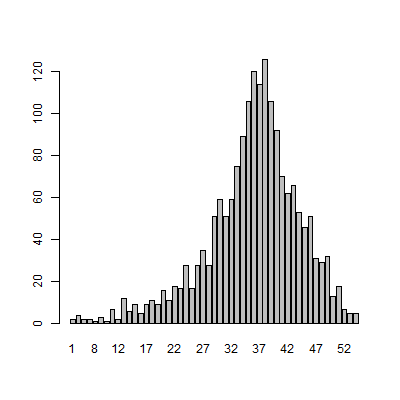

### Distribución de frecuencias léxicas (Zipf)

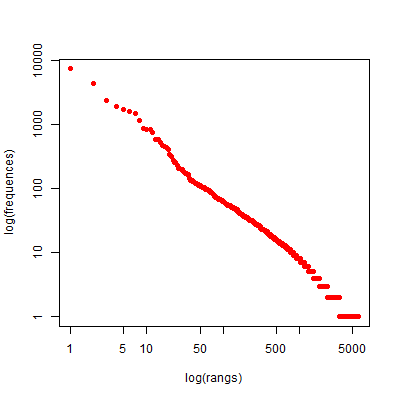

### Nube de palabras

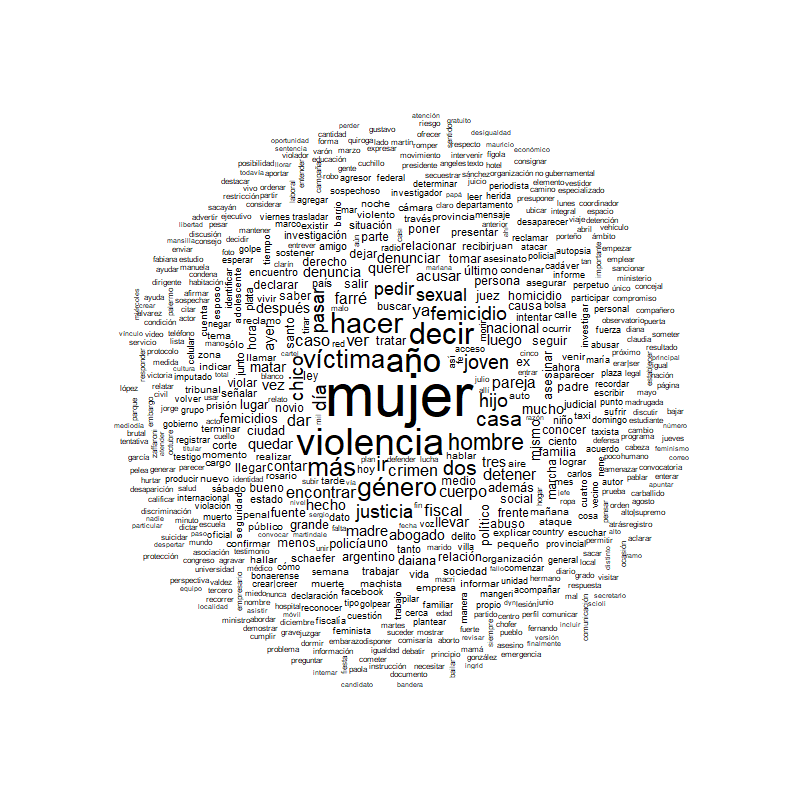

### Análisis de similitud

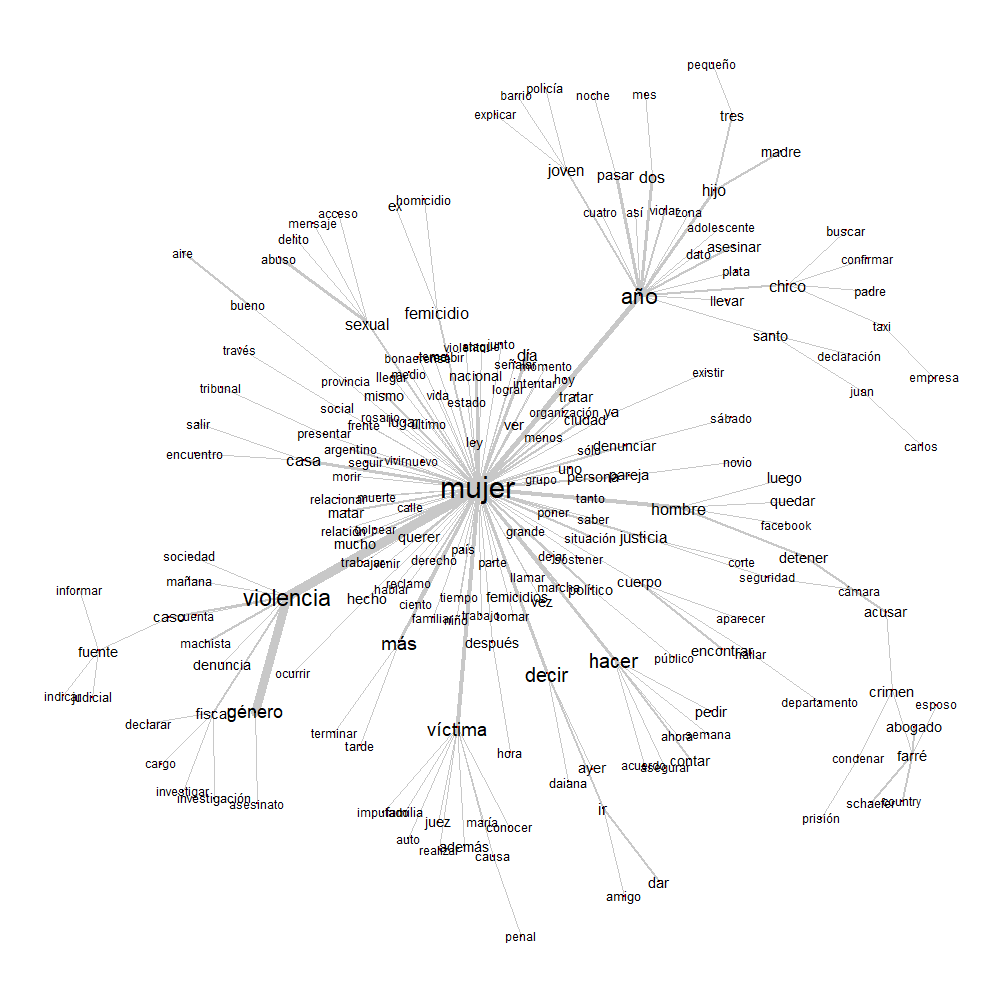

In [12]:
describe_year(
    "argentina",
    2015,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2015,
)

### Clasificación jerárquica descendente

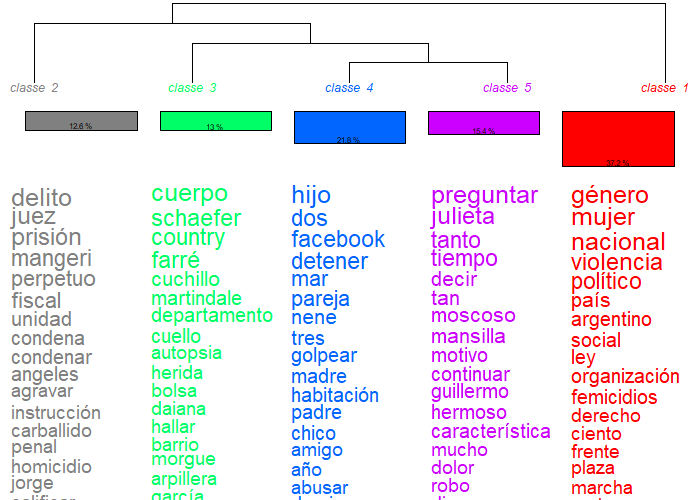

In [13]:
show_chd(
    "argentina",
    2015,
    alceste_run=2,
)

## Argentina — 2016



El corpus correspondiente a **Argentina en 2016**
está compuesto por **225 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2016

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2016_corpus_1


### Distribución del tamaño de los segmentos

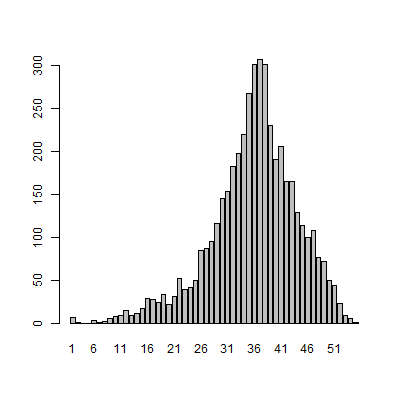

### Distribución de frecuencias léxicas (Zipf)

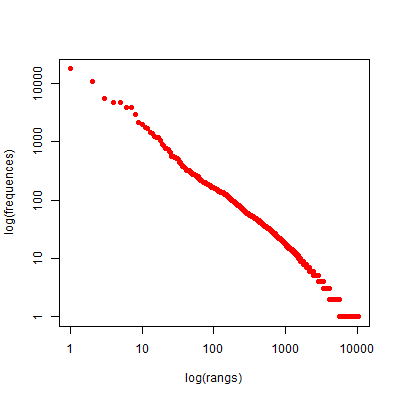

### Nube de palabras

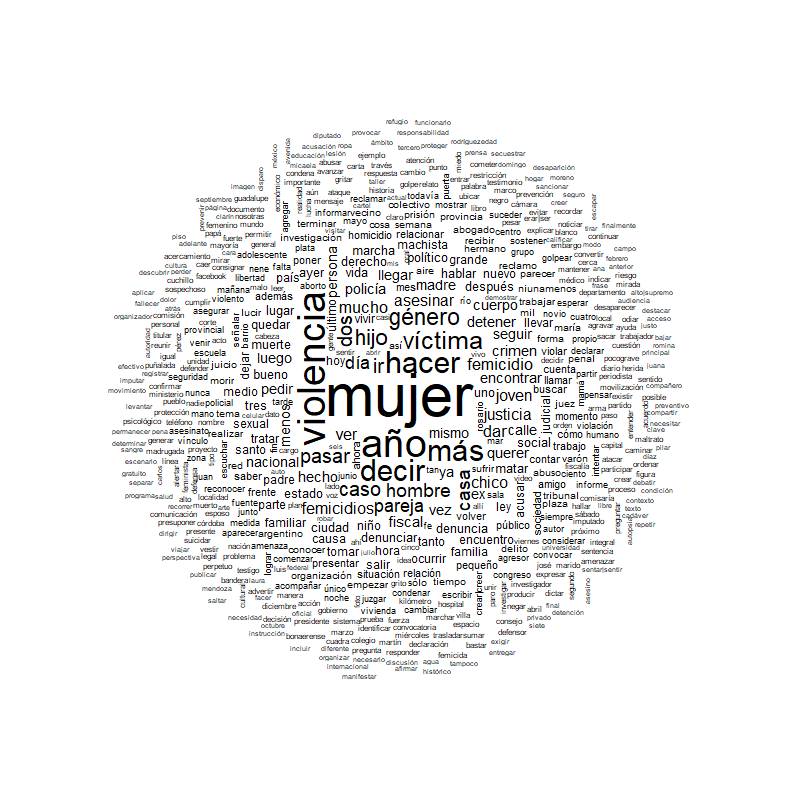

### Análisis de similitud

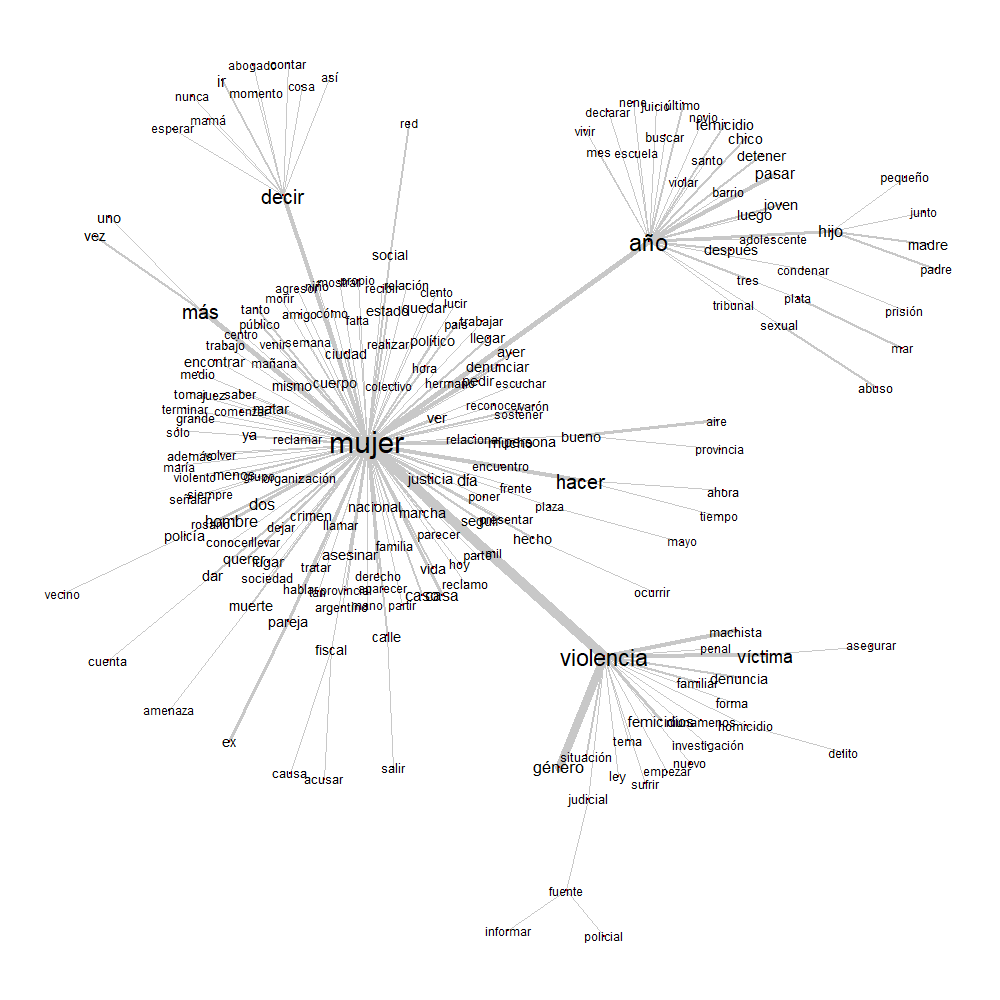

In [14]:
describe_year(
    "argentina",
    2016,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2016,
)

### Clasificación jerárquica descendente

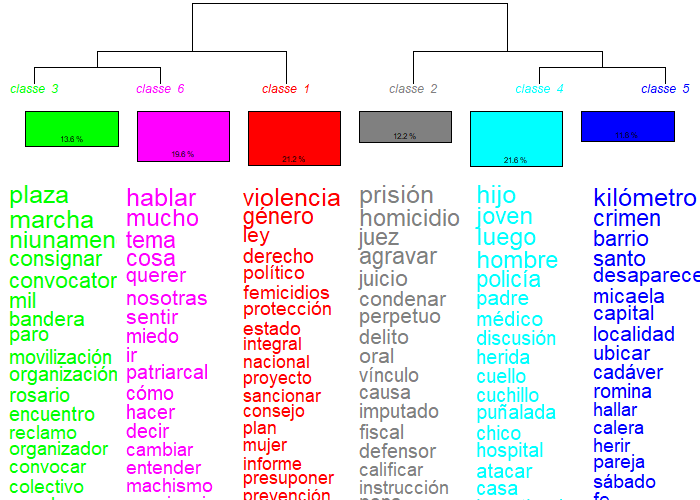

In [15]:
show_chd(
    "argentina",
    2016,
    alceste_run=1,
)

## Argentina 2017



El corpus correspondiente a **Argentina en 2017**
está compuesto por **103 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2017

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2017_corpus_1


### Distribución del tamaño de los segmentos

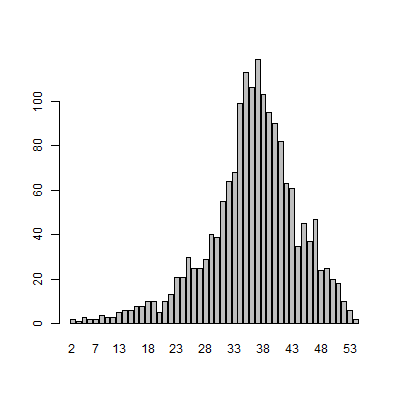

### Distribución de frecuencias léxicas (Zipf)

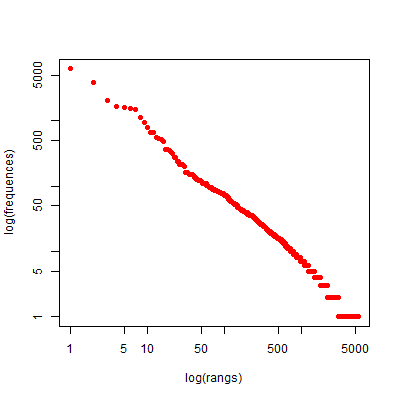

### Nube de palabras

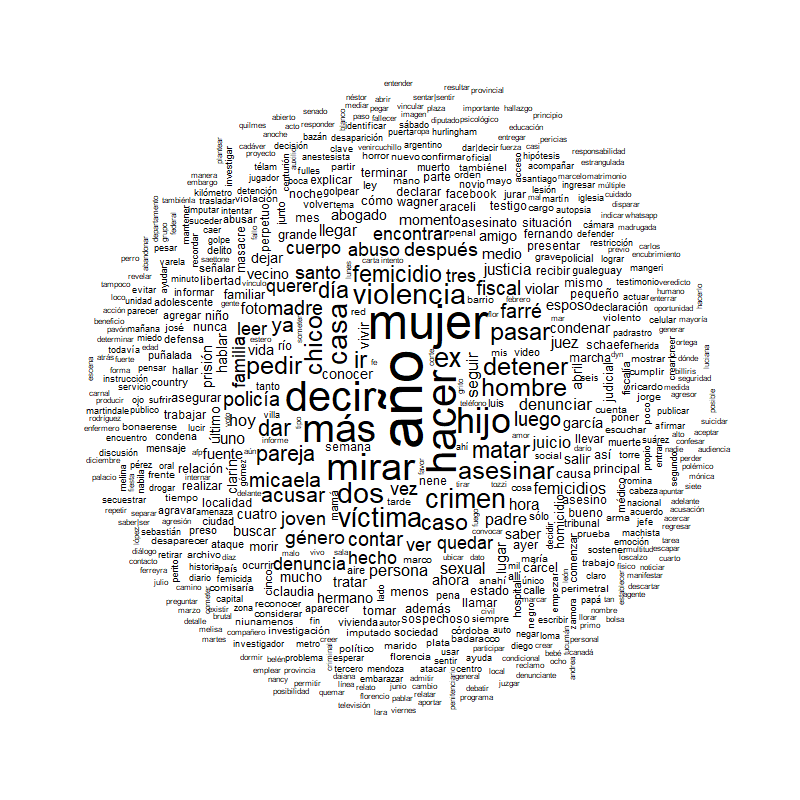

### Análisis de similitud

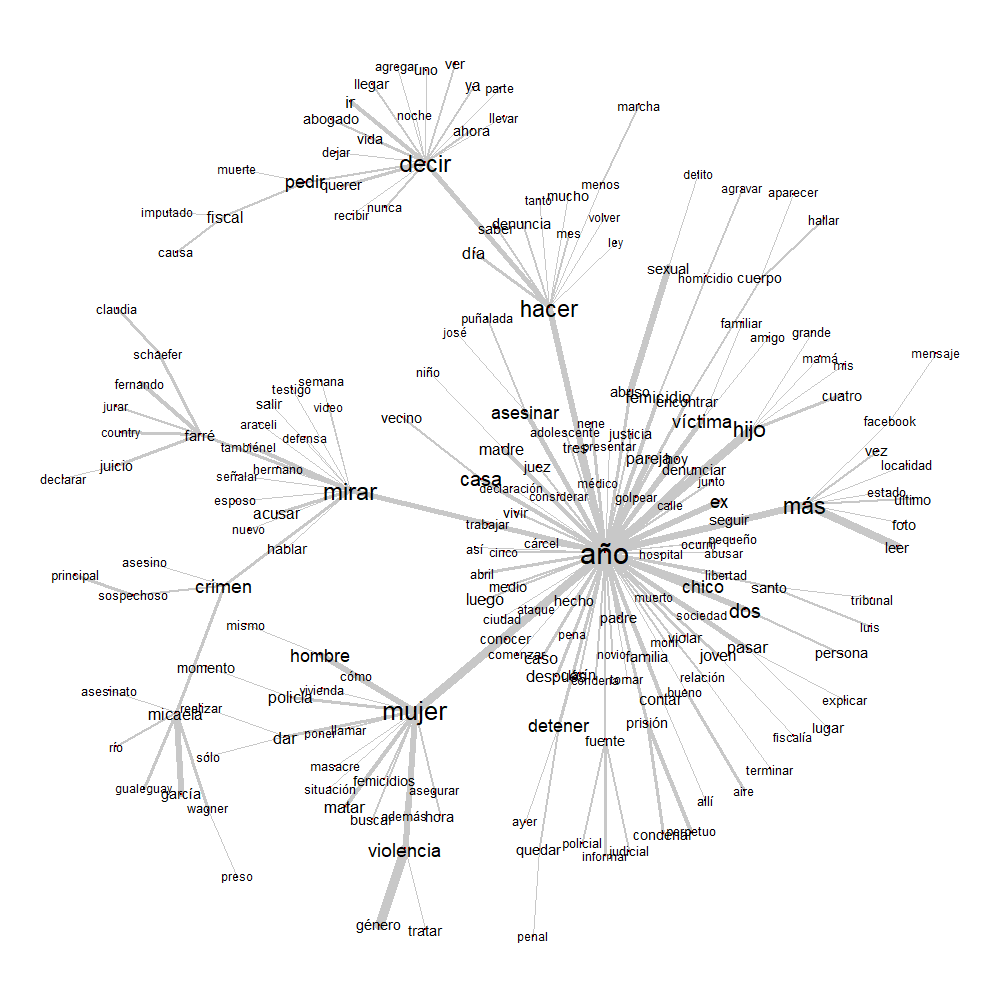

In [16]:
describe_year(
    "argentina",
    2017,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2017,
)

### Clasificación jerárquica descendente

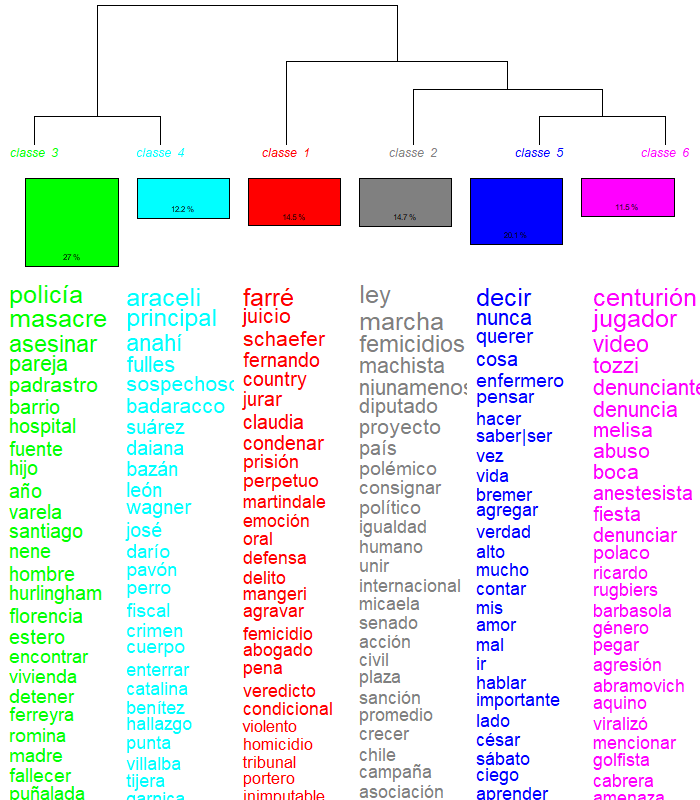

In [17]:
show_chd(
    "argentina",
    2017,
    alceste_run=1,
)

## Argentina 2018



El corpus correspondiente a **Argentina en 2018**
está compuesto por **63 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2018

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2018_corpus_1


### Distribución del tamaño de los segmentos

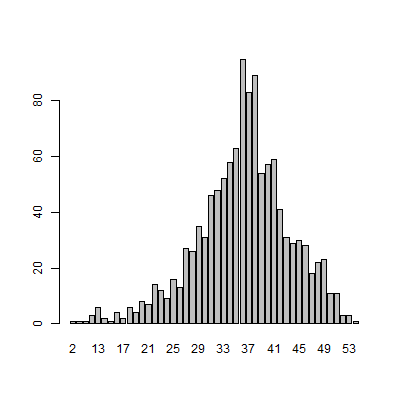

### Distribución de frecuencias léxicas (Zipf)

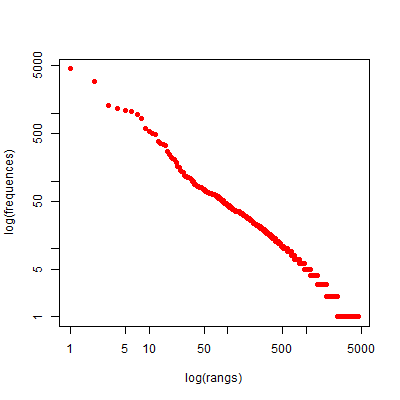

### Nube de palabras

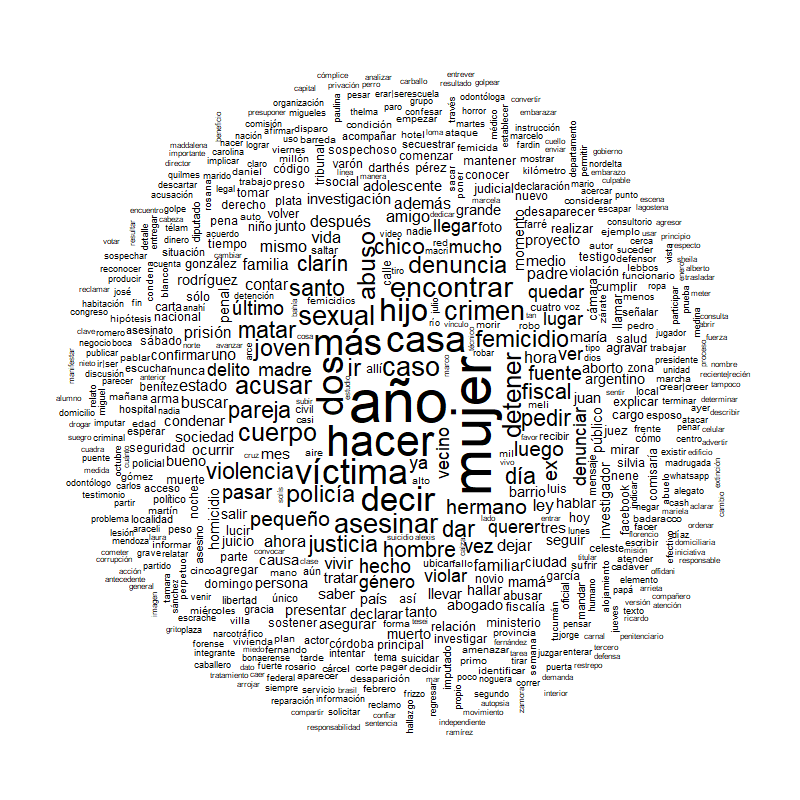

### Análisis de similitud

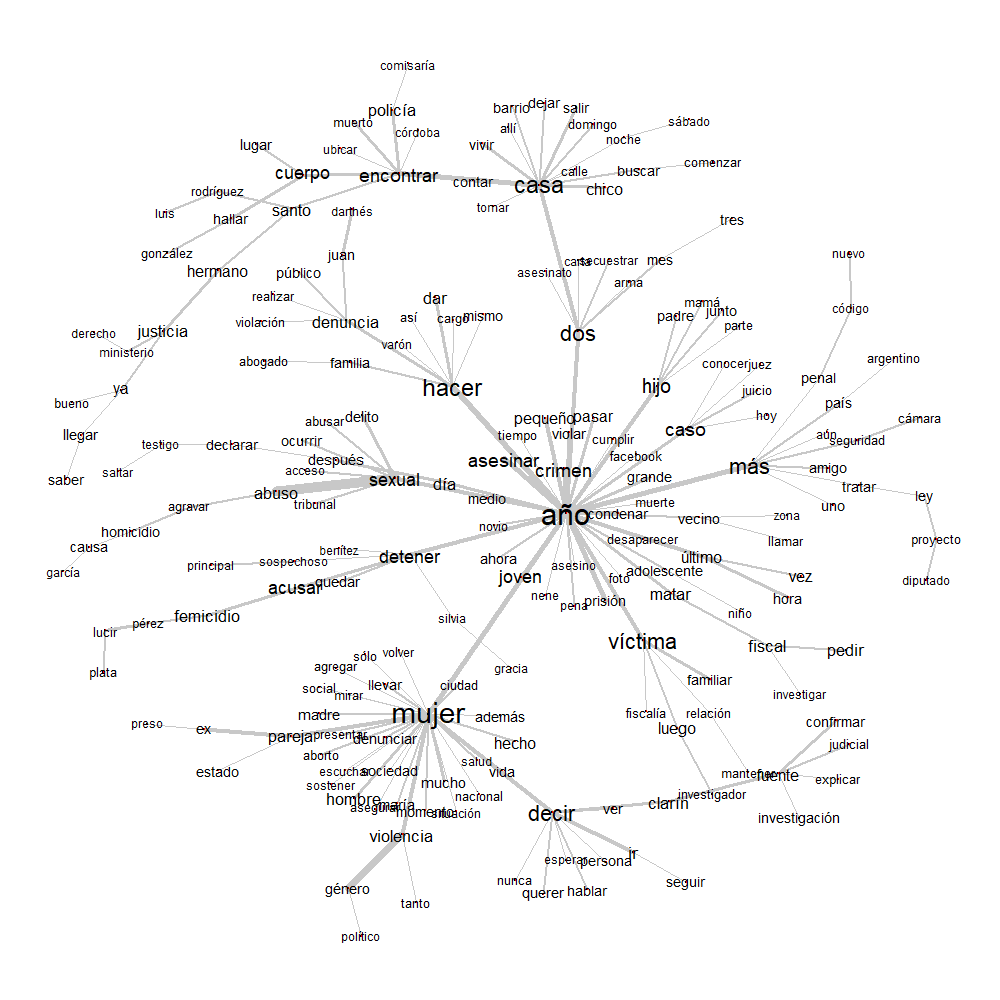

In [18]:
describe_year(
    "argentina",
    2018,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2018,
)

### Clasificación jerárquica descendente

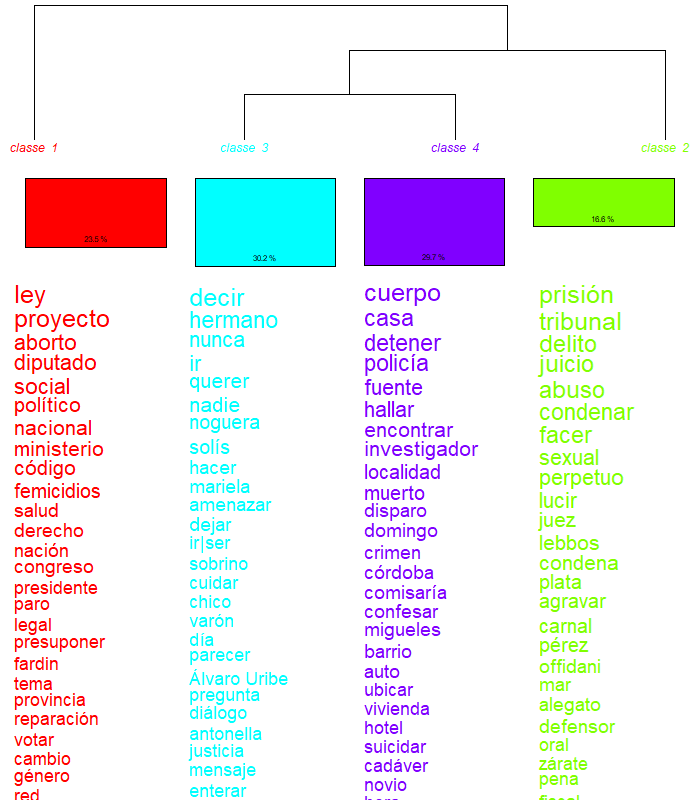

In [19]:
show_chd(
    "argentina",
    2018,
    alceste_run=1,
)

## Argentina 2019



El corpus correspondiente a **Argentina en 2019**
está compuesto por **61 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2019

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2019_corpus_1


### Distribución del tamaño de los segmentos

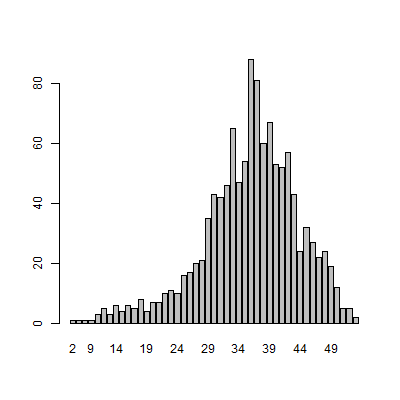

### Distribución de frecuencias léxicas (Zipf)

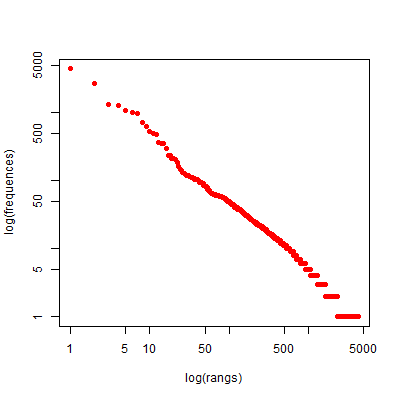

### Nube de palabras

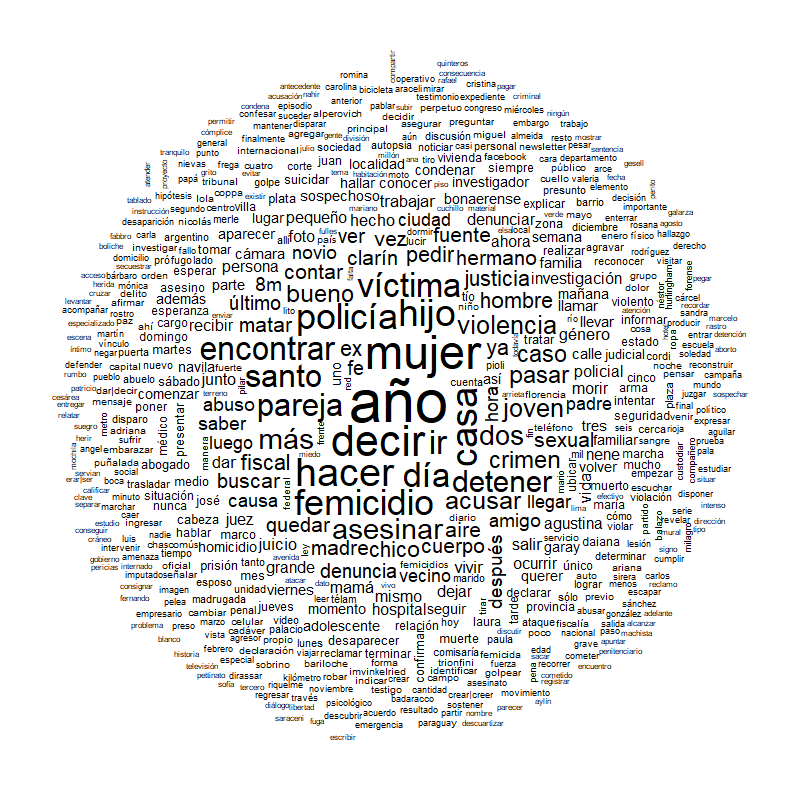

### Análisis de similitud

Resultado no encontrado: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2019_corpus_1\corpus_argentina_2019_simitxt_1\graph_simi_1.png


In [20]:
describe_year(
    "argentina",
    2019,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2019,
)

### Clasificación jerárquica descendente

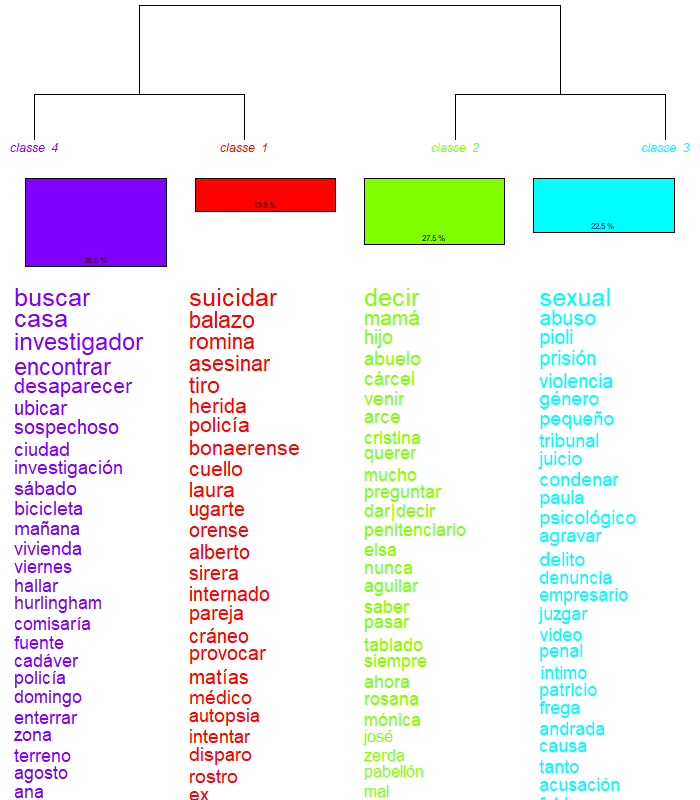

In [21]:
show_chd(
    "argentina",
    2019,
    alceste_run=1,
)

## Argentina 2020



El corpus correspondiente a **Argentina en 2020**
está compuesto por **51 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2020

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2020_corpus_1


### Distribución del tamaño de los segmentos

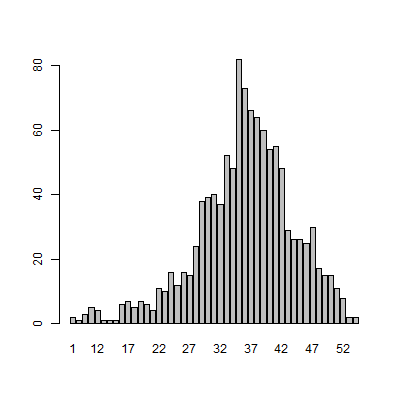

### Distribución de frecuencias léxicas (Zipf)

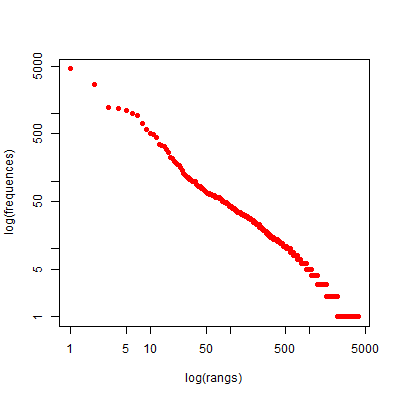

### Nube de palabras

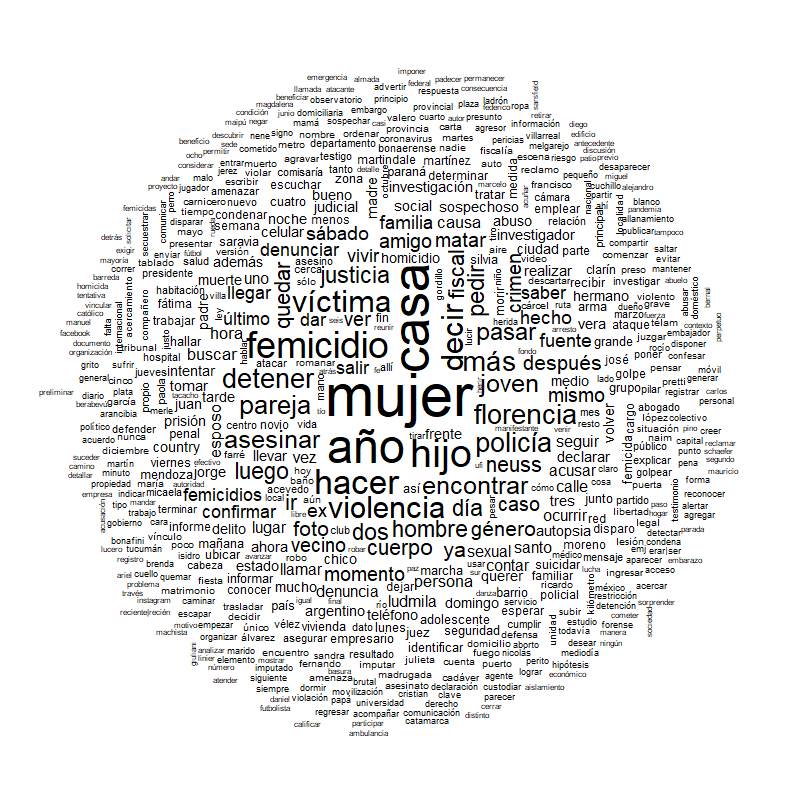

### Análisis de similitud

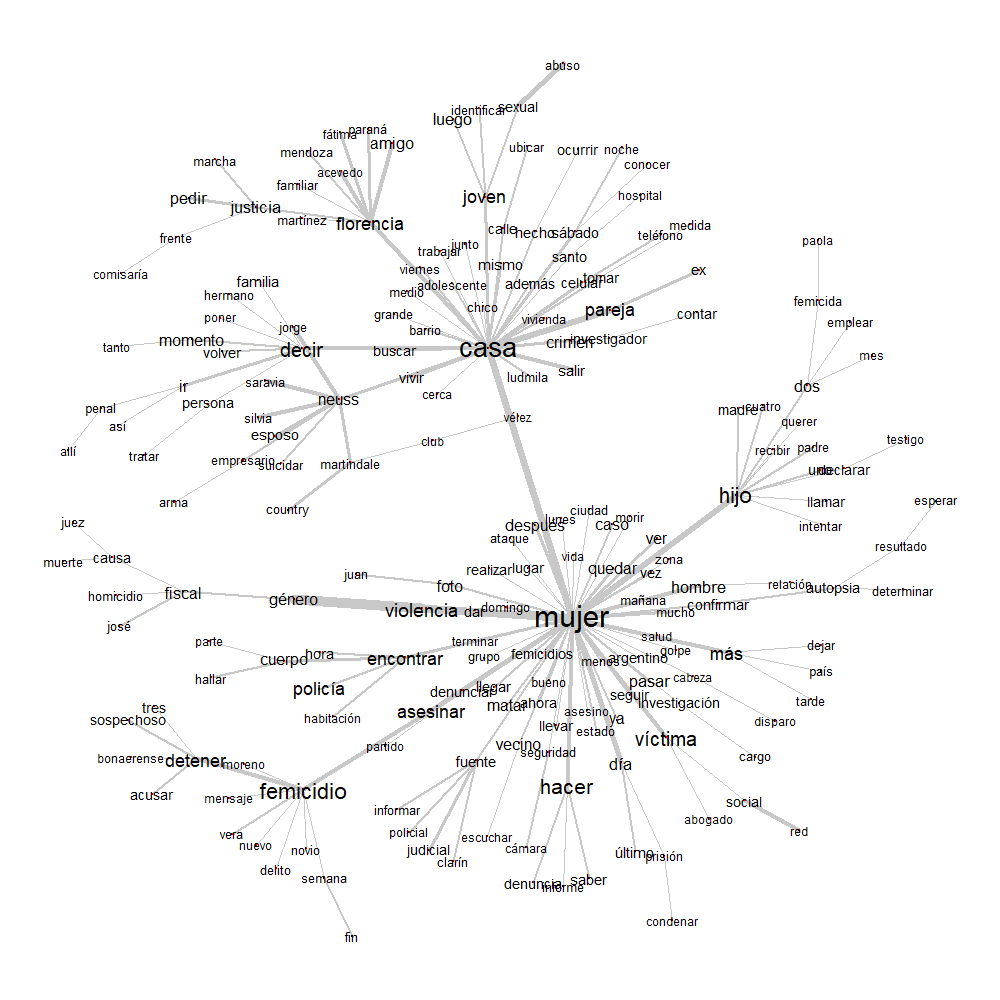

In [22]:
describe_year(
    "argentina",
    2020,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2020,
)

### Clasificación jerárquica descendente

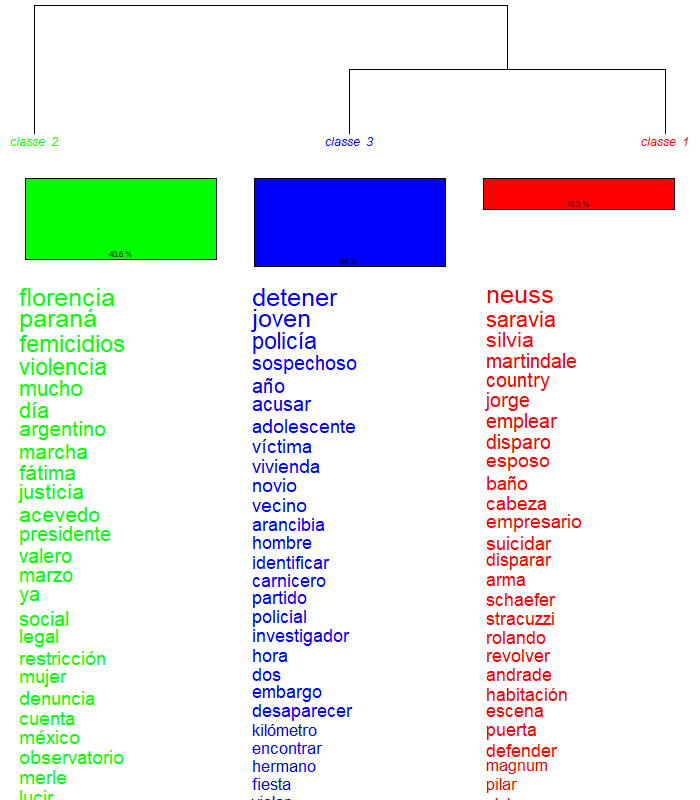

In [23]:
show_chd(
    "argentina",
    2020,
    alceste_run=1,
)

## Argentina 2021



El corpus correspondiente a **Argentina en 2021**
está compuesto por **50 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2021

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2021_corpus_1


### Distribución del tamaño de los segmentos

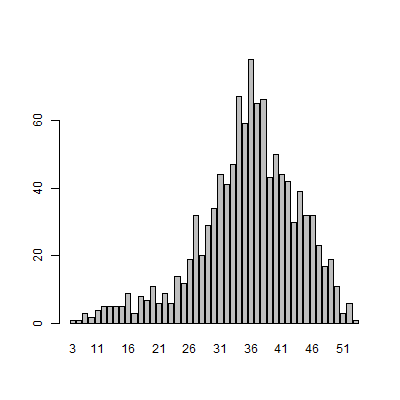

### Distribución de frecuencias léxicas (Zipf)

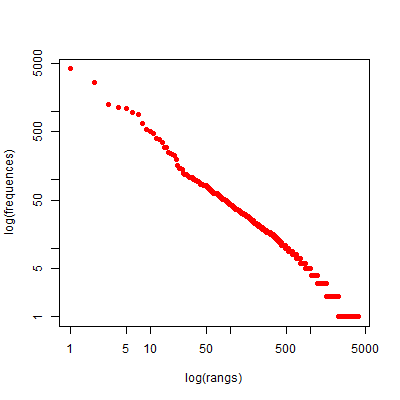

### Nube de palabras

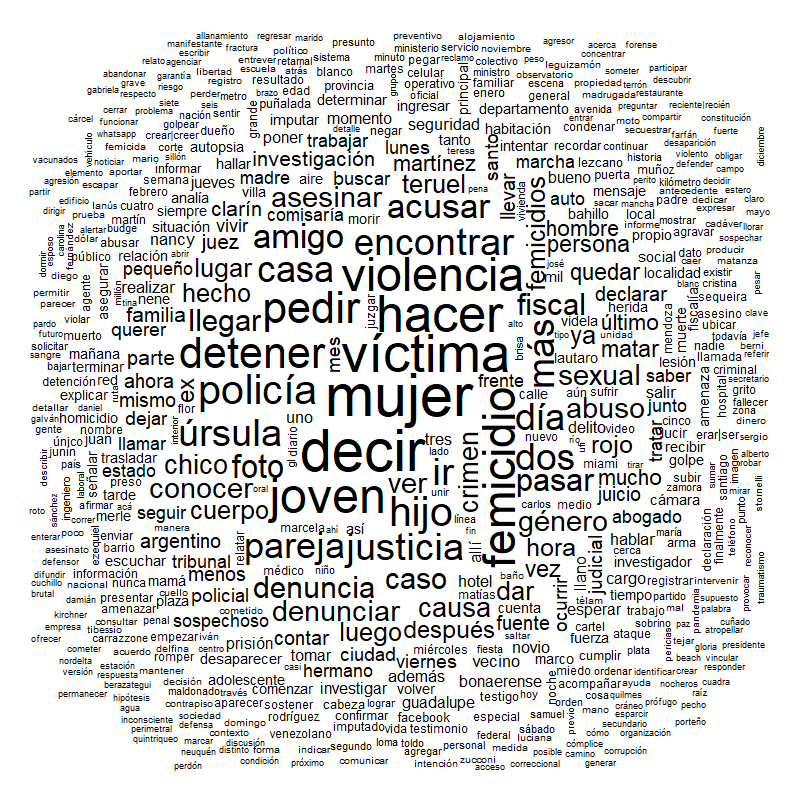

### Análisis de similitud

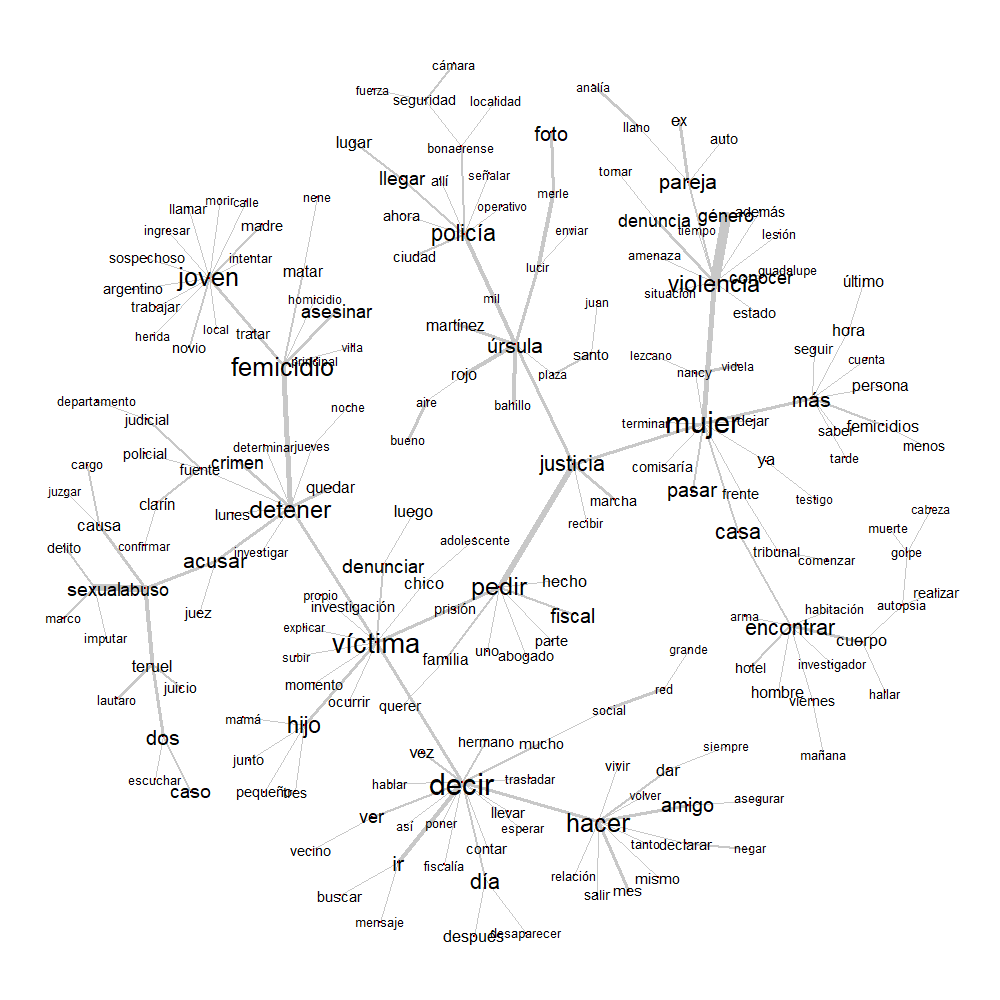

In [24]:
describe_year(
    "argentina",
    2021,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2021,
)

### Clasificación jerárquica descendente

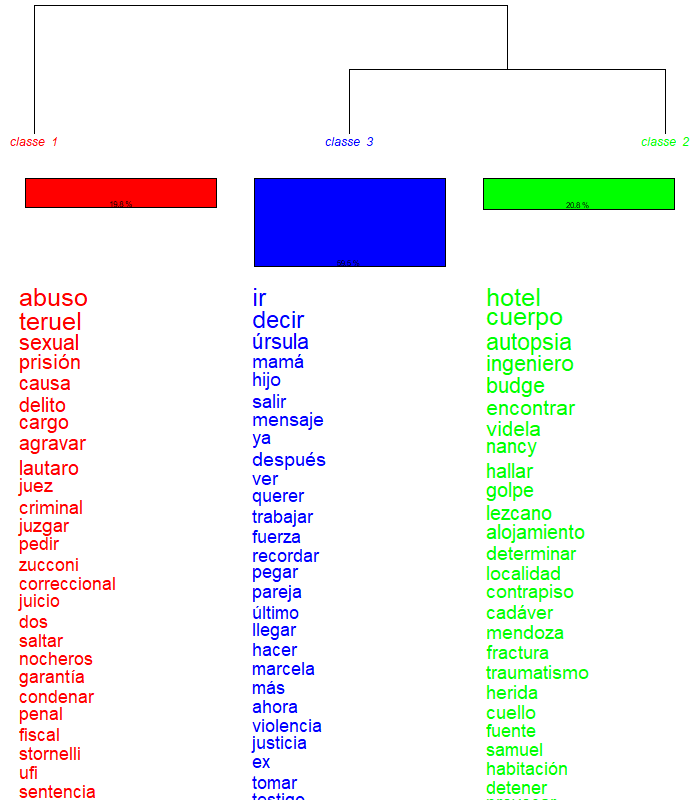

In [25]:
show_chd(
    "argentina",
    2021,
    alceste_run=1,
)

## Argentina 2022



El corpus correspondiente a **Argentina en 2022**
está compuesto por **31 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2022

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2022_corpus_1


### Distribución del tamaño de los segmentos

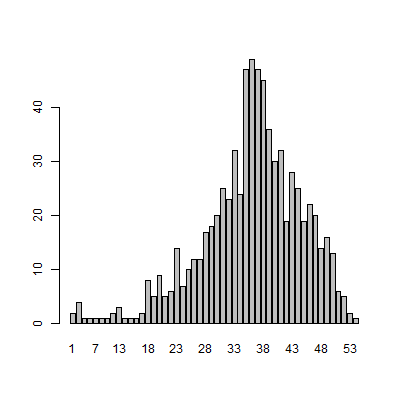

### Distribución de frecuencias léxicas (Zipf)

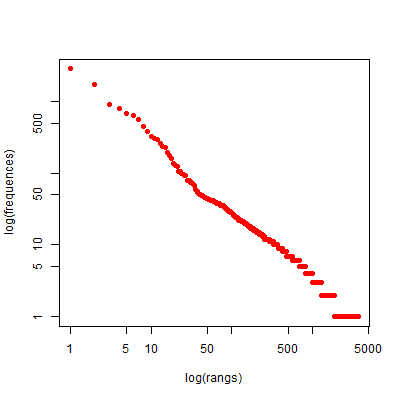

### Nube de palabras

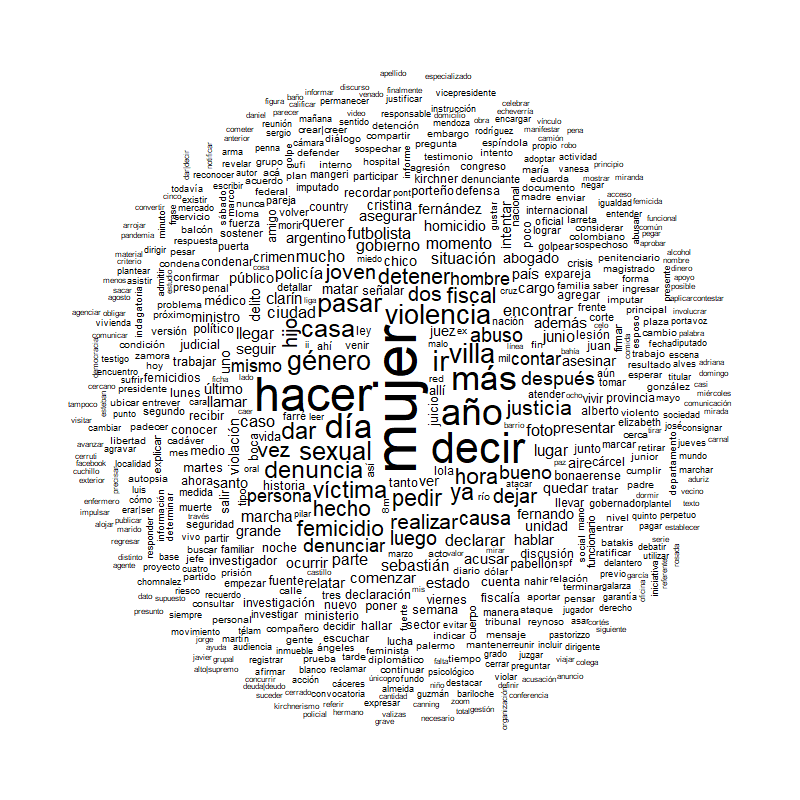

### Análisis de similitud

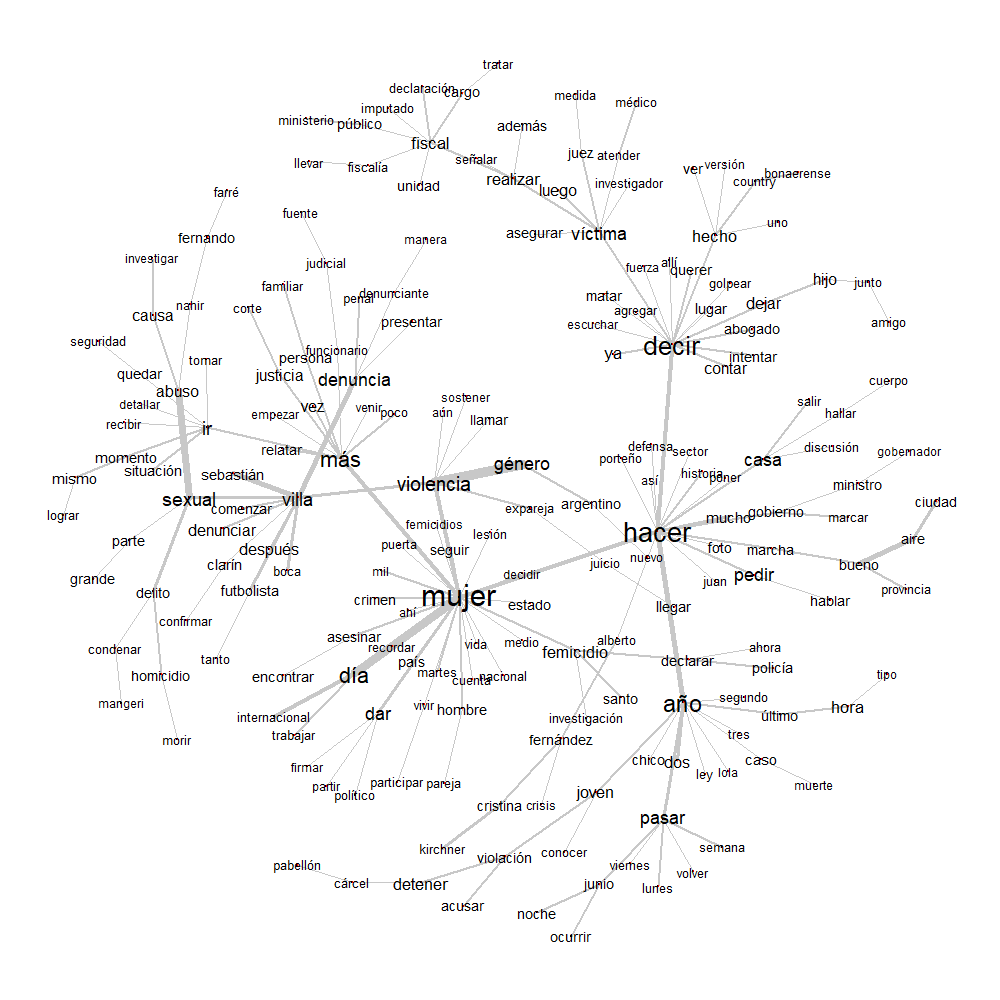

In [26]:
describe_year(
    "argentina",
    2022,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2022,
)

### Clasificación jerárquica descendente

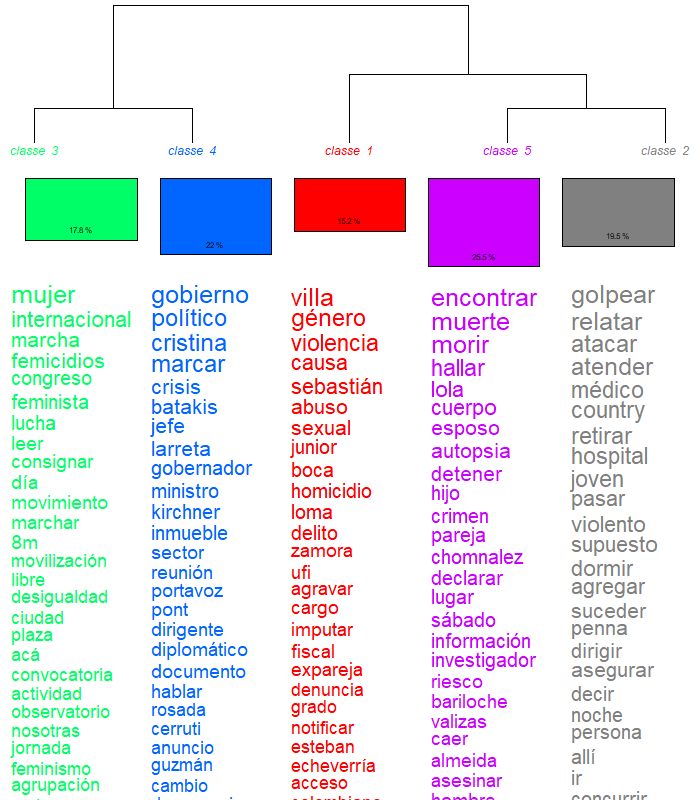

In [27]:
show_chd(
    "argentina",
    2022,
    alceste_run=1,
)

## Argentina 2023



El corpus correspondiente a **Argentina en 2023**
está compuesto por **217 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2023

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2023_corpus_1


### Distribución del tamaño de los segmentos

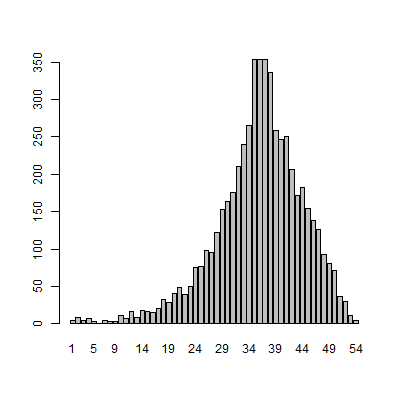

### Distribución de frecuencias léxicas (Zipf)

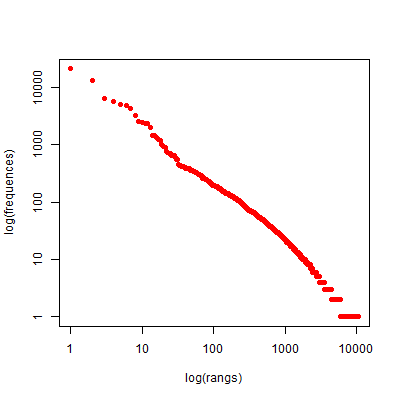

### Nube de palabras

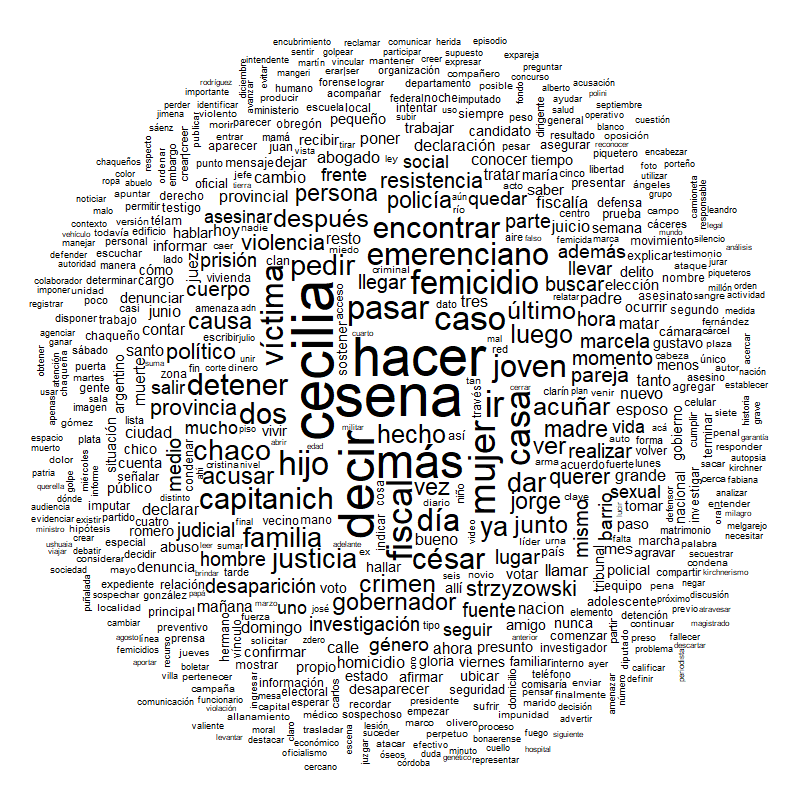

### Análisis de similitud

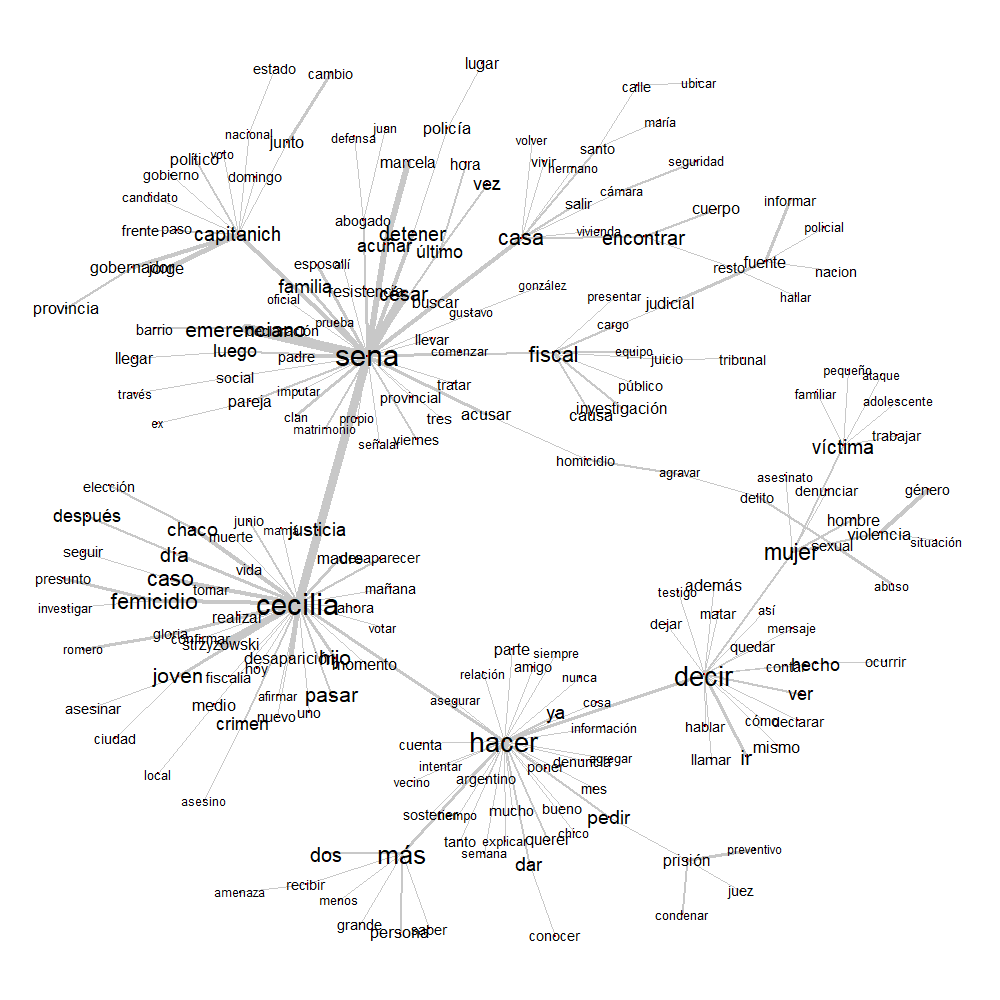

In [28]:
describe_year(
    "argentina",
    2023,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2023,
)

### Clasificación jerárquica descendente

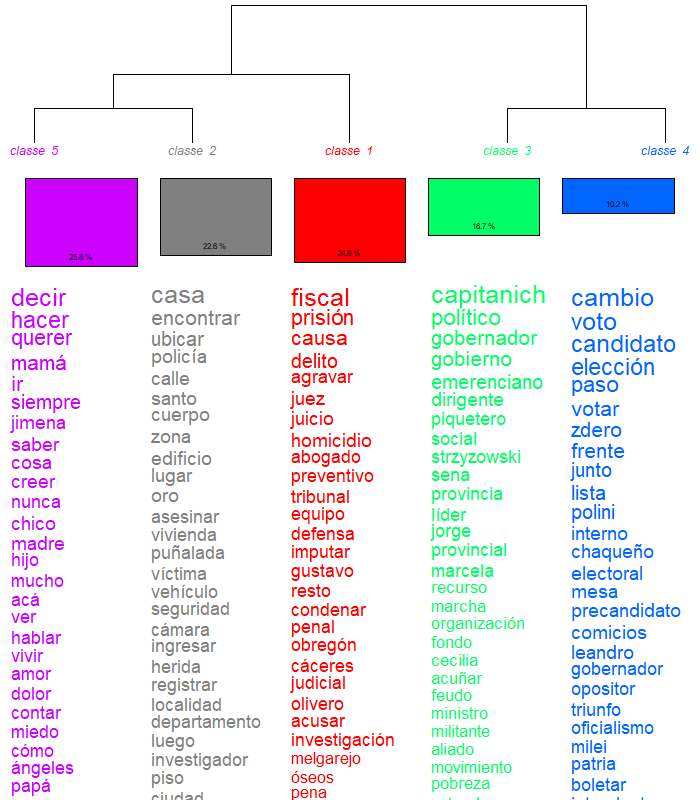

In [29]:
show_chd(
    "argentina",
    2023,
    alceste_run=1,
)

## Argentina 2024



El corpus correspondiente a **Argentina en 2024**
está compuesto por **105 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2024

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2024_corpus_1


### Distribución del tamaño de los segmentos

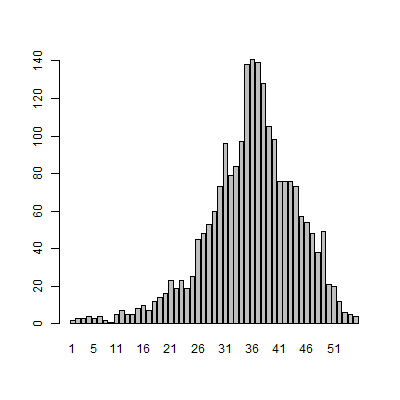

### Distribución de frecuencias léxicas (Zipf)

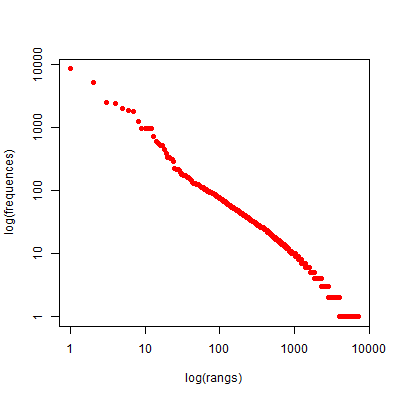

### Nube de palabras

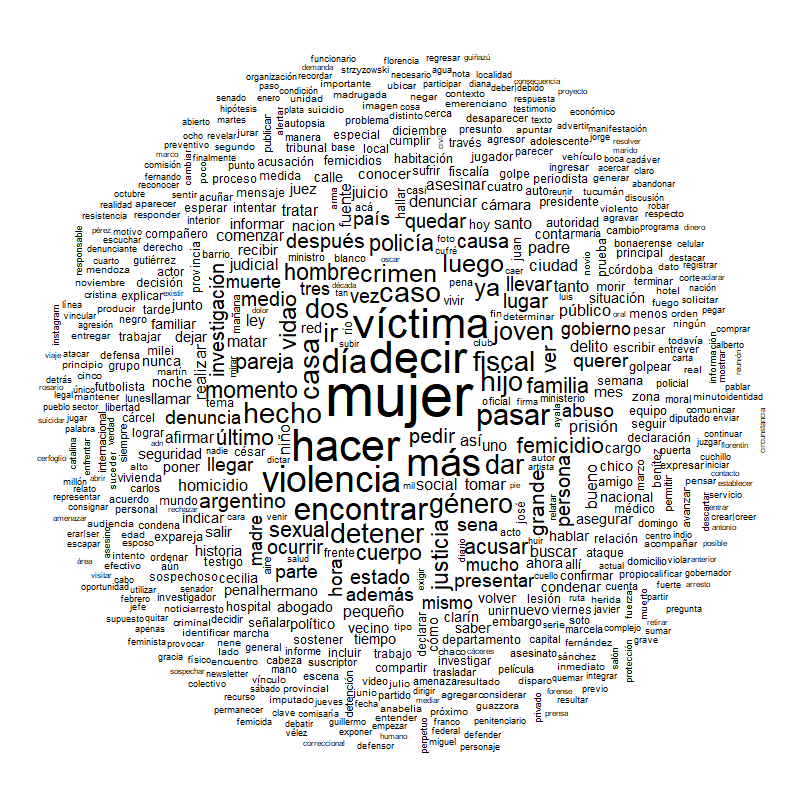

### Análisis de similitud

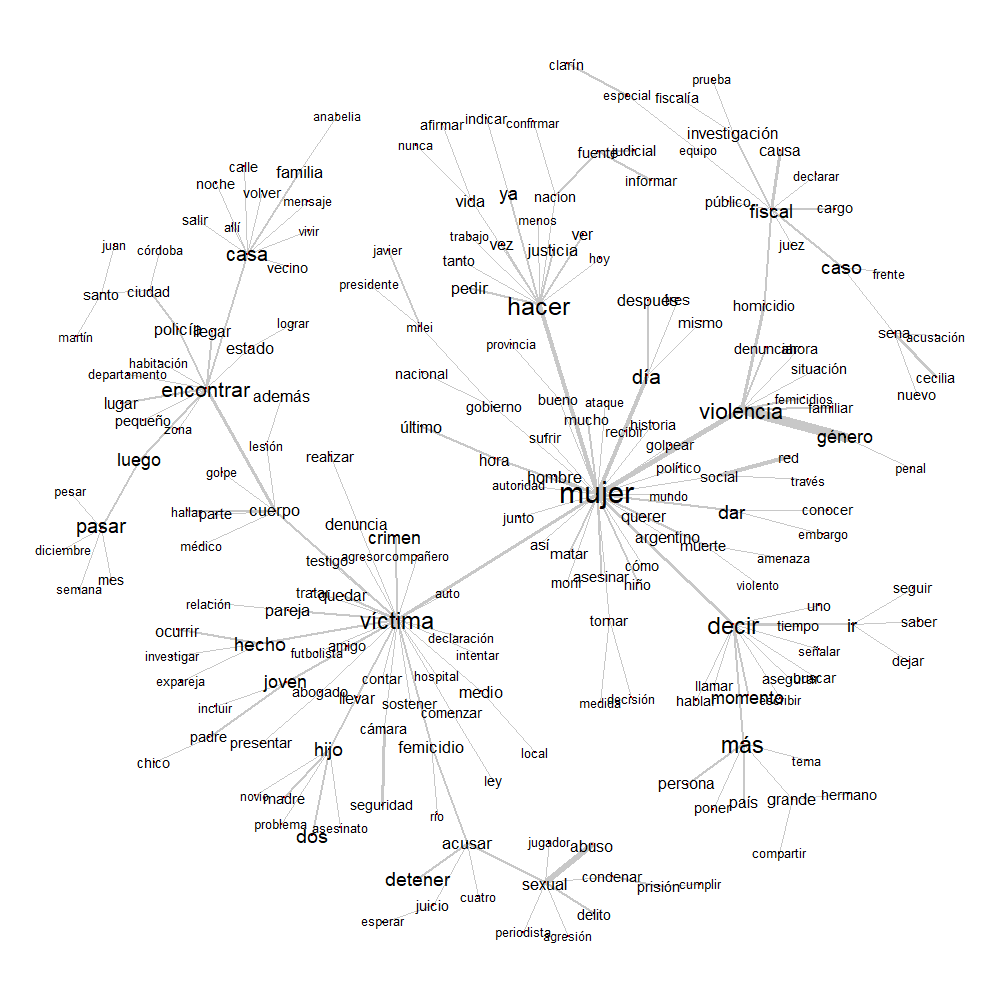

In [30]:
describe_year(
    "argentina",
    2024,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2024,
)

### Clasificación jerárquica descendente

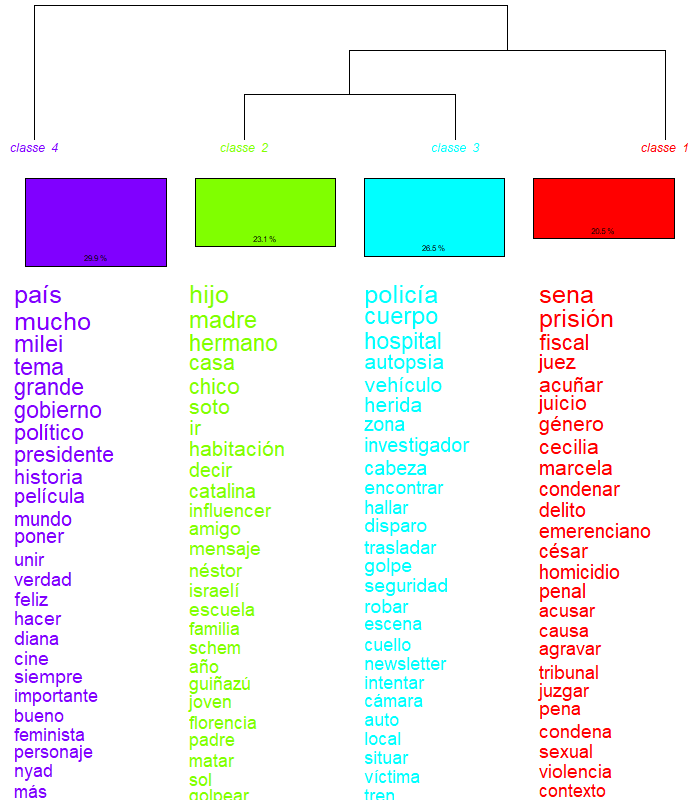

In [31]:
show_chd(
    "argentina",
    2024,
    alceste_run=1,
)

## Argentina 2025



El corpus correspondiente a **Argentina en 2025**
está compuesto por **179 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Argentina — 2025

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\by_year\corpus_argentina_2025_corpus_1


### Distribución del tamaño de los segmentos

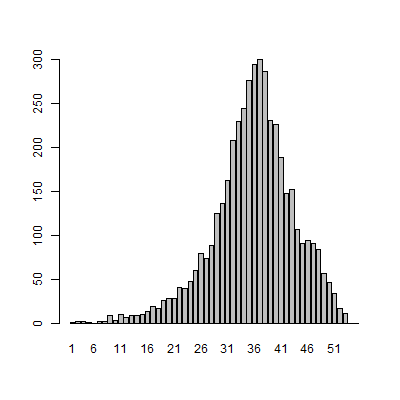

### Distribución de frecuencias léxicas (Zipf)

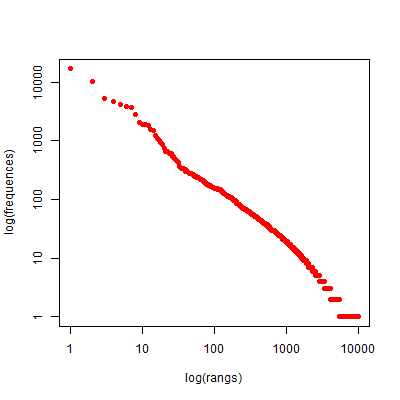

### Nube de palabras

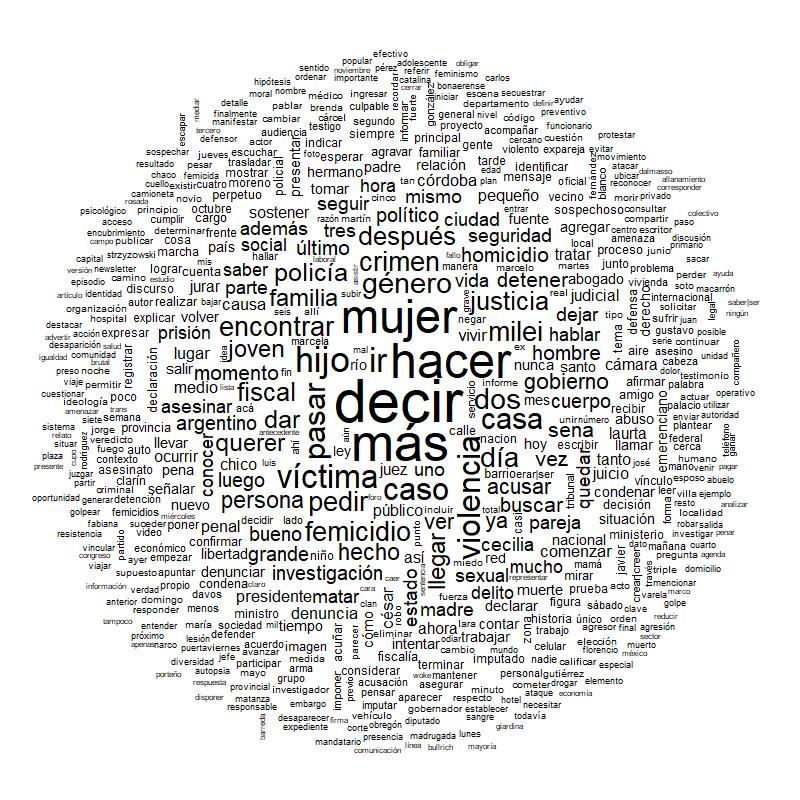

### Análisis de similitud

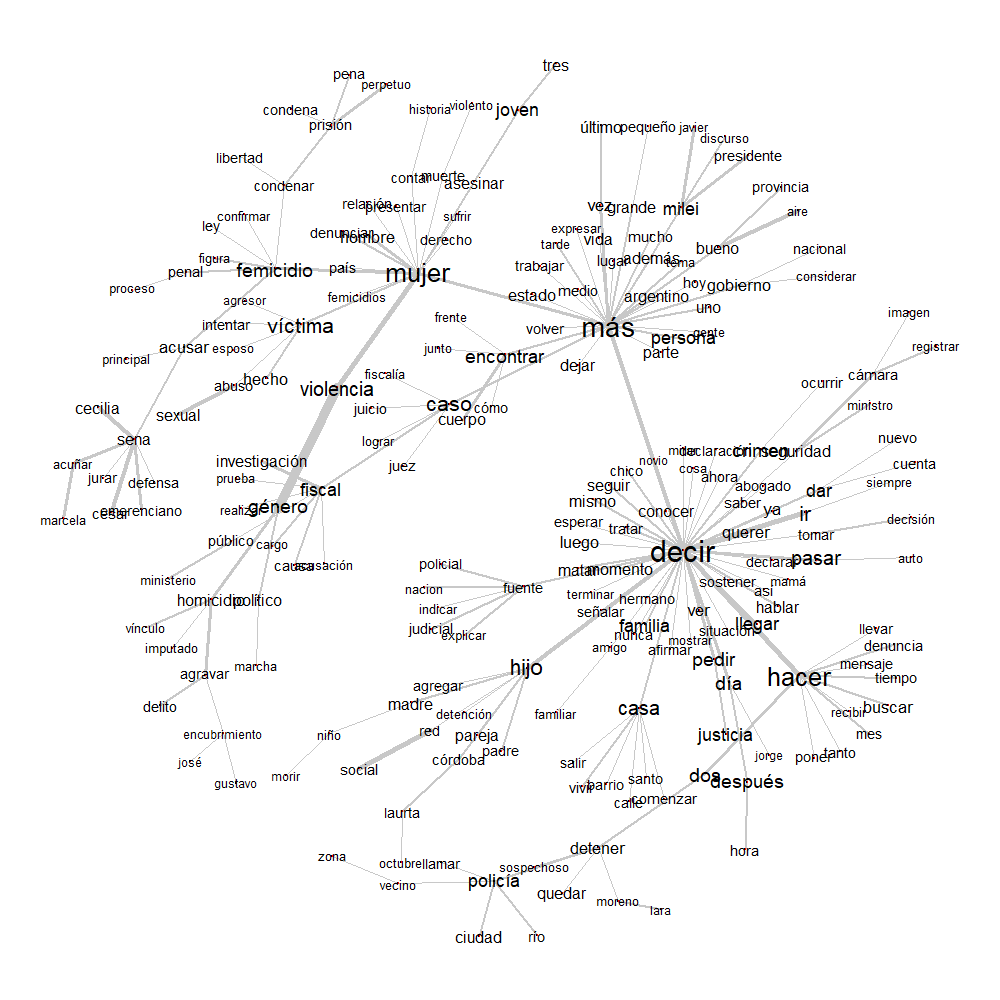

In [32]:
describe_year(
    "argentina",
    2025,
    argentina_manifest,
)

show_results(
    "argentina",
    year=2025,
)

### Clasificación jerárquica descendente

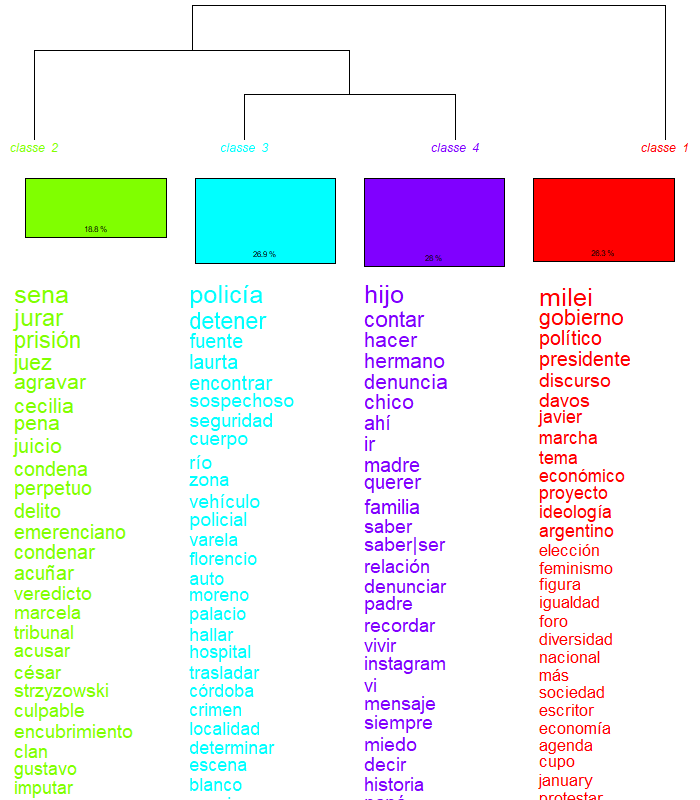

In [33]:
show_chd(
    "argentina",
    2025,
    alceste_run=1,
)

## México 2015



El corpus correspondiente a **Mexico en 2015**
está compuesto por **56 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2015

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2015_corpus_1


### Distribución del tamaño de los segmentos

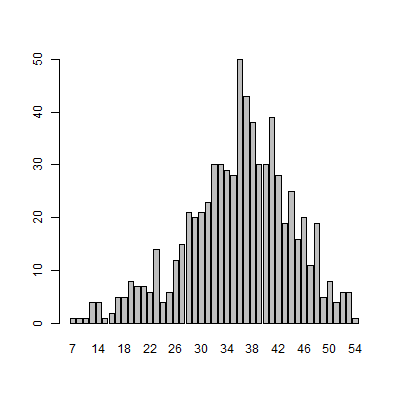

### Distribución de frecuencias léxicas (Zipf)

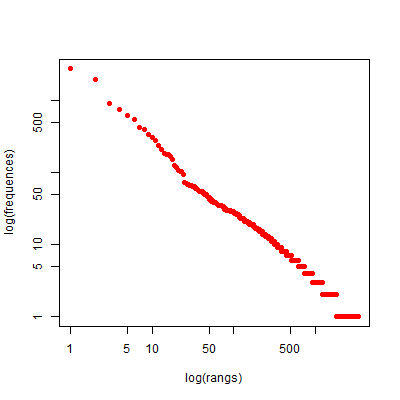

### Nube de palabras

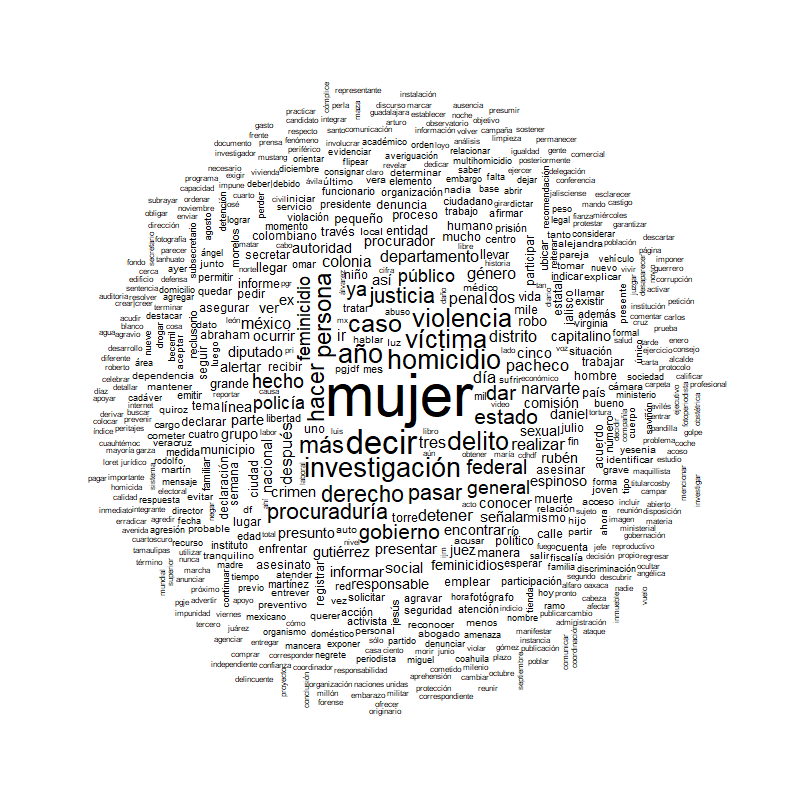

### Análisis de similitud

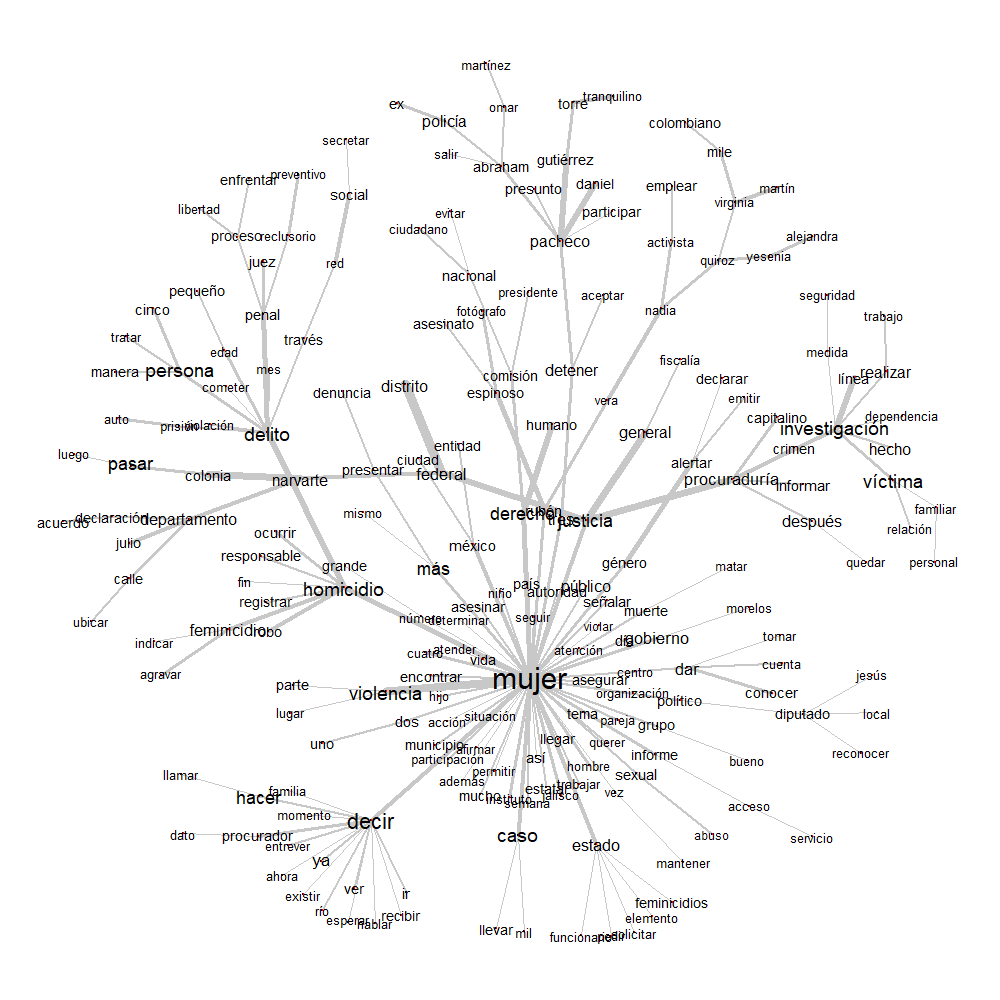

In [34]:
describe_year(
    "mexico",
    2015,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2015,
)

### Clasificación jerárquica descendente

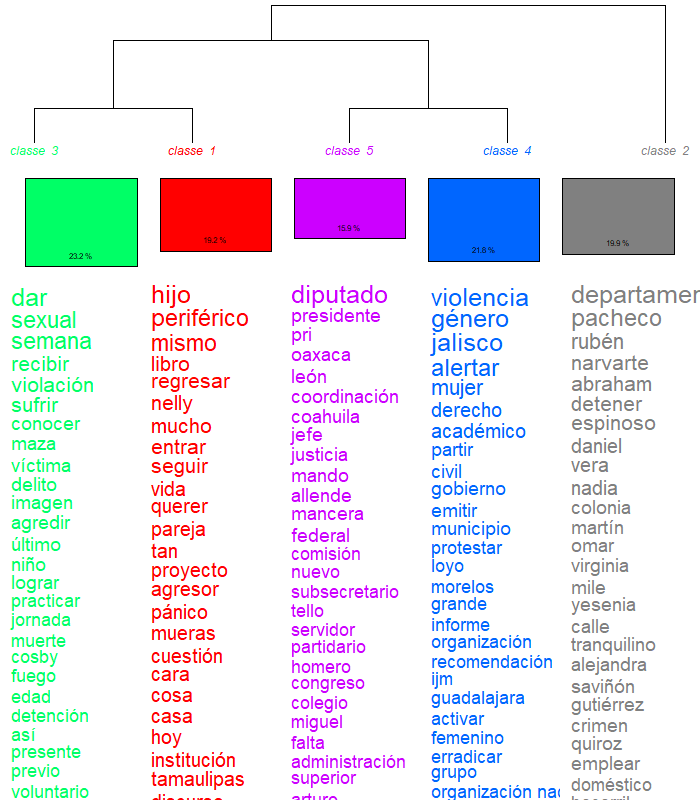

In [35]:
show_chd(
    "mexico",
    2015,
    alceste_run=1,
)

## México 2016



El corpus correspondiente a **Mexico en 2016**
está compuesto por **49 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2016

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2016_corpus_1


### Distribución del tamaño de los segmentos

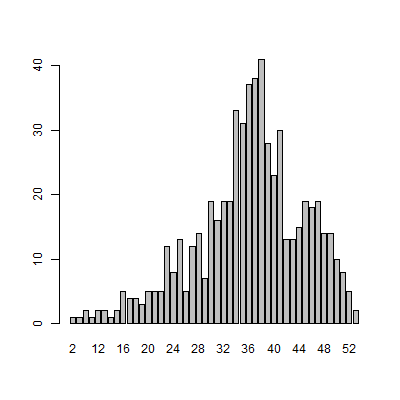

### Distribución de frecuencias léxicas (Zipf)

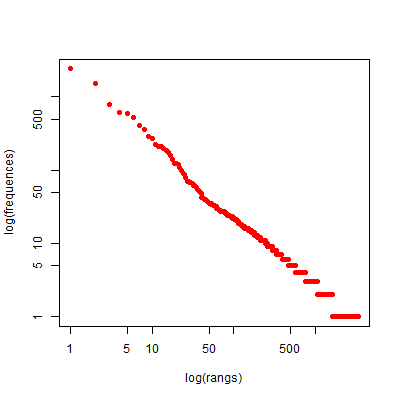

### Nube de palabras

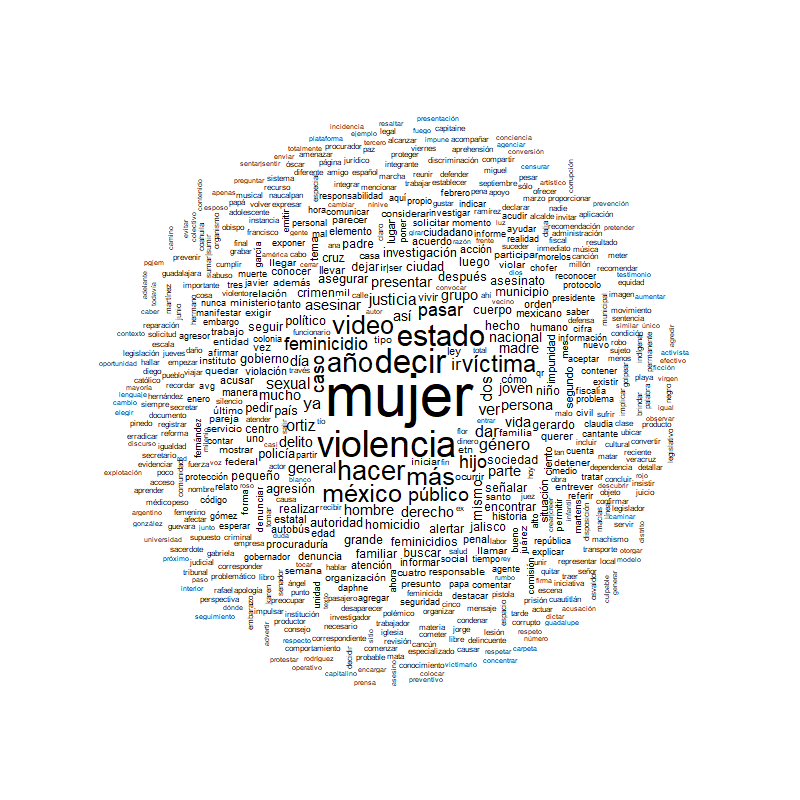

### Análisis de similitud

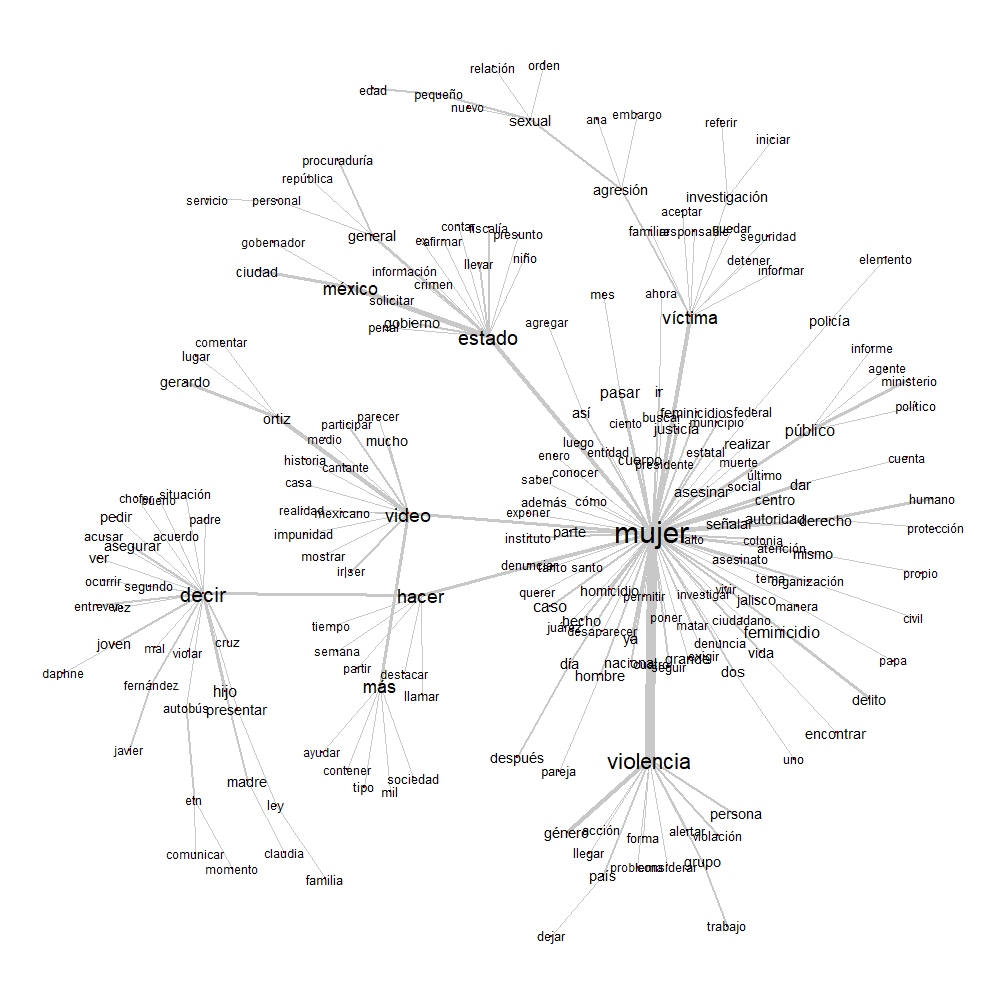

In [36]:
describe_year(
    "mexico",
    2016,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2016,
)

### Clasificación jerárquica descendente

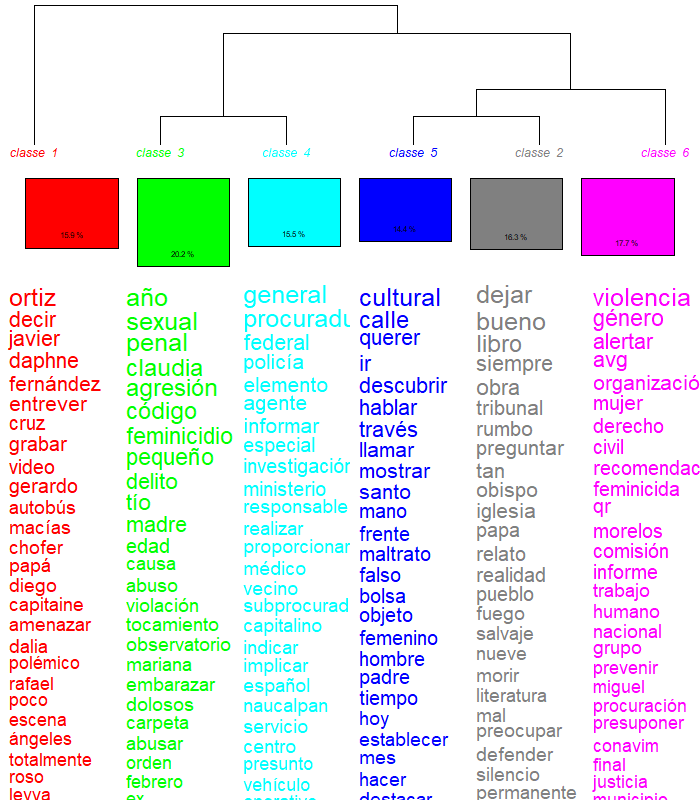

In [37]:
show_chd(
    "mexico",
    2016,
    alceste_run=1,
)

## México 2017



El corpus correspondiente a **Mexico en 2017**
está compuesto por **99 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2017

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2017_corpus_1


### Distribución del tamaño de los segmentos

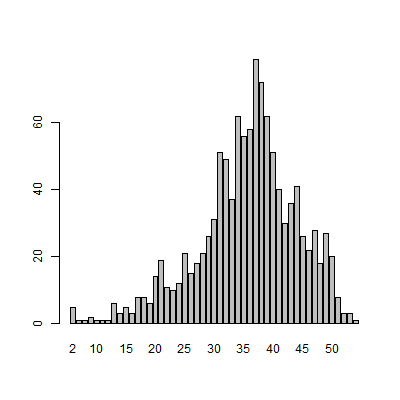

### Distribución de frecuencias léxicas (Zipf)

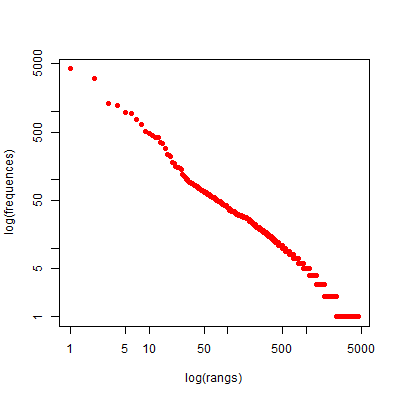

### Nube de palabras

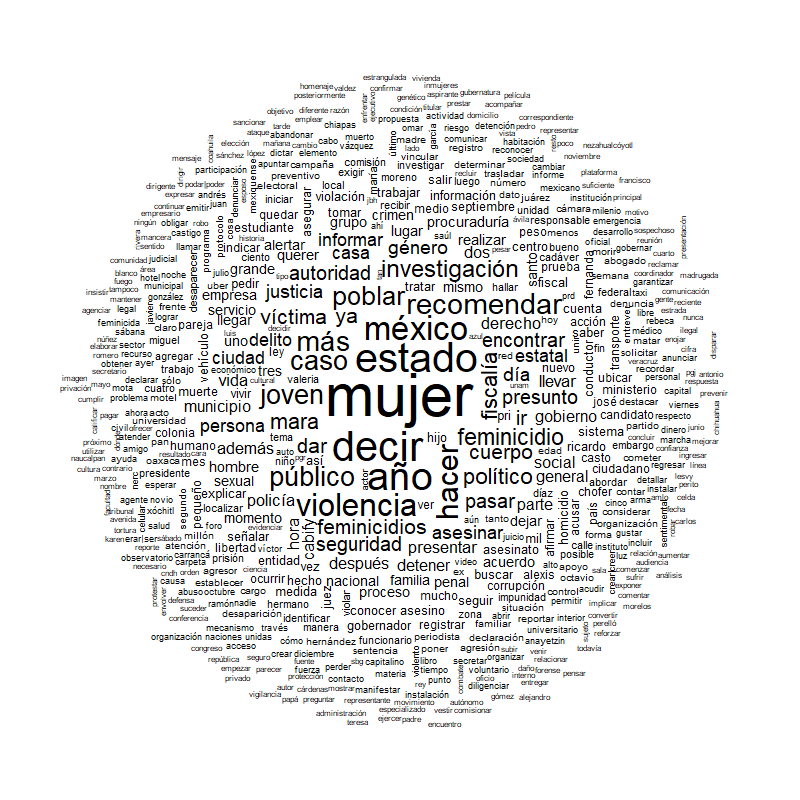

### Análisis de similitud

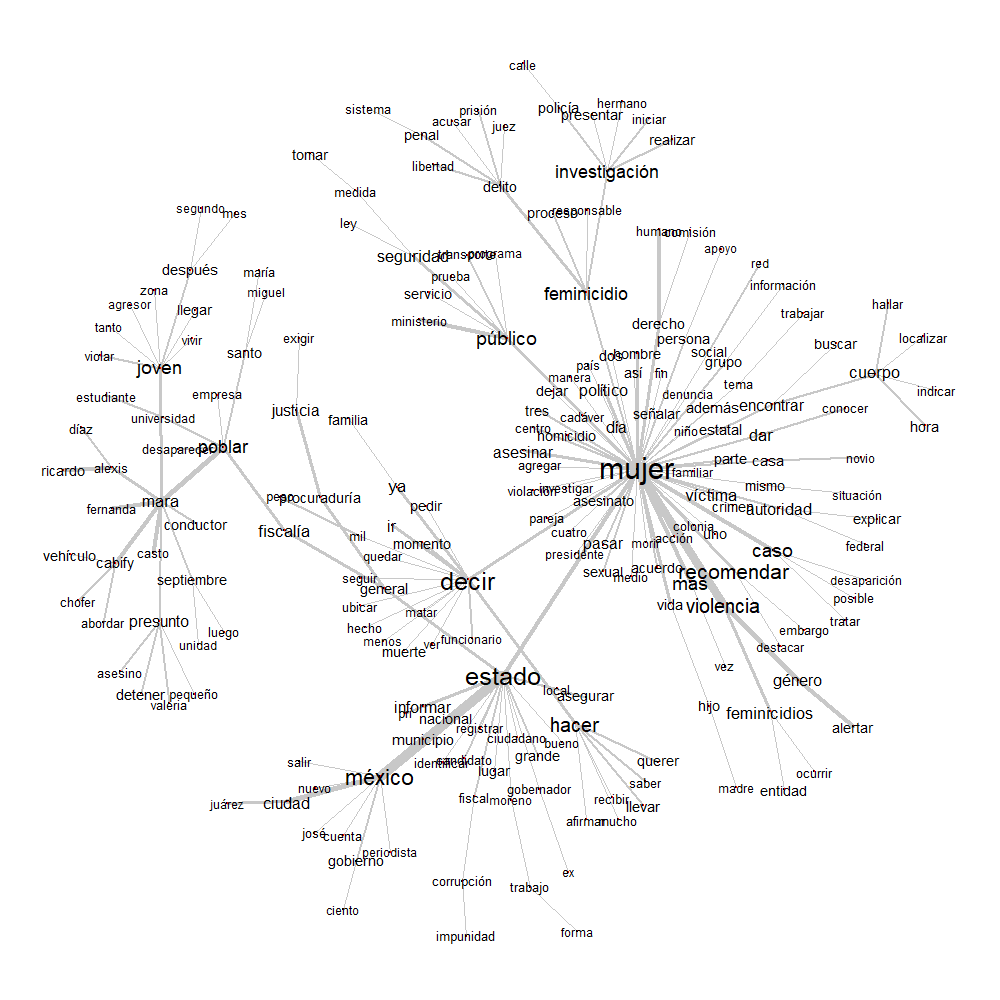

In [38]:
describe_year(
    "mexico",
    2017,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2017,
)

### Clasificación jerárquica descendente

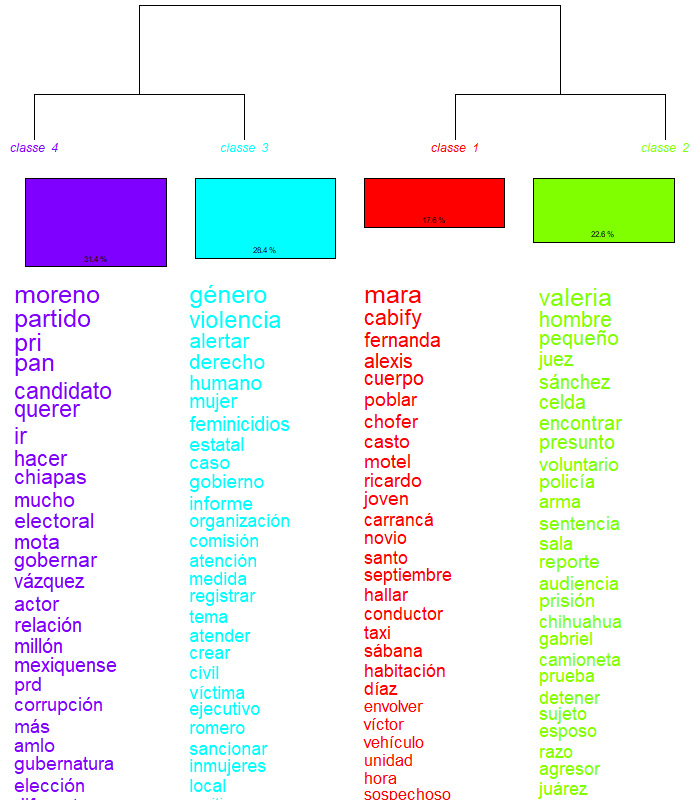

In [39]:
show_chd(
    "mexico",
    2017,
    alceste_run=1,
)

## México 2018



El corpus correspondiente a **Mexico en 2018**
está compuesto por **68 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2018

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2018_corpus_1


### Distribución del tamaño de los segmentos

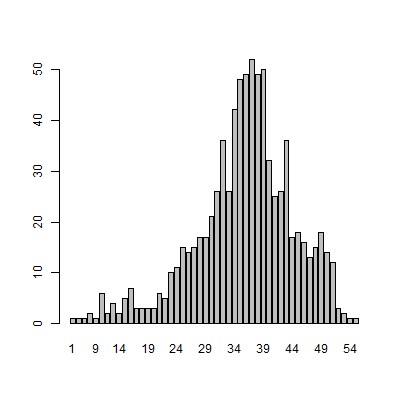

### Distribución de frecuencias léxicas (Zipf)

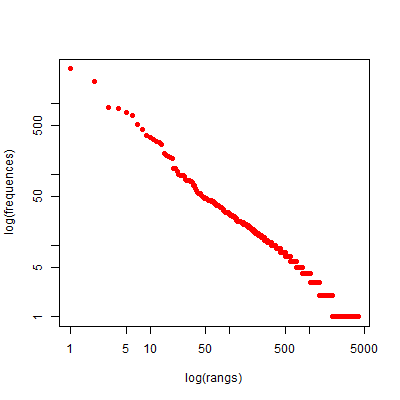

### Nube de palabras

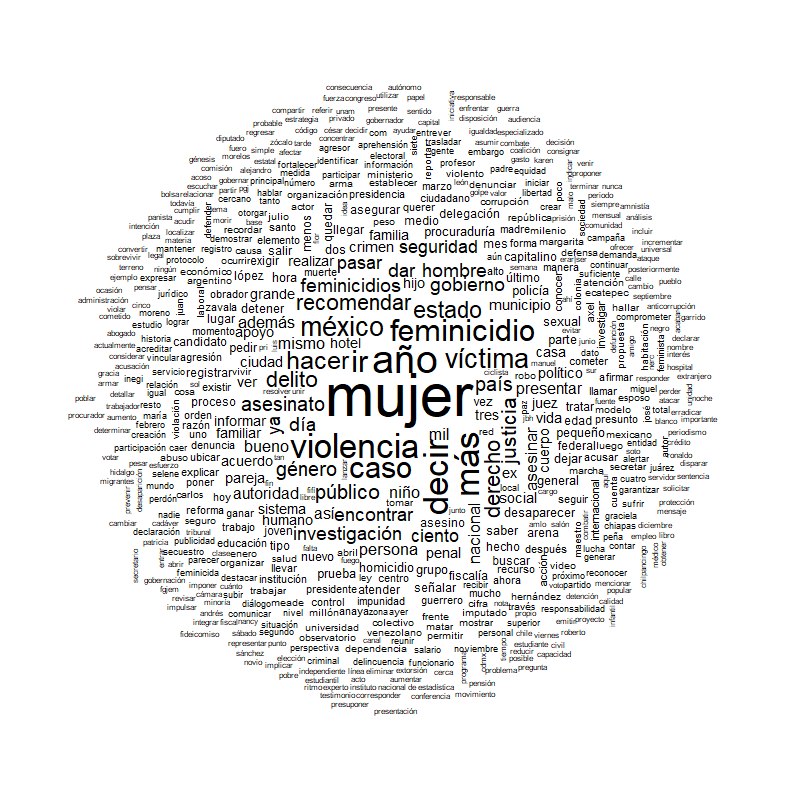

### Análisis de similitud

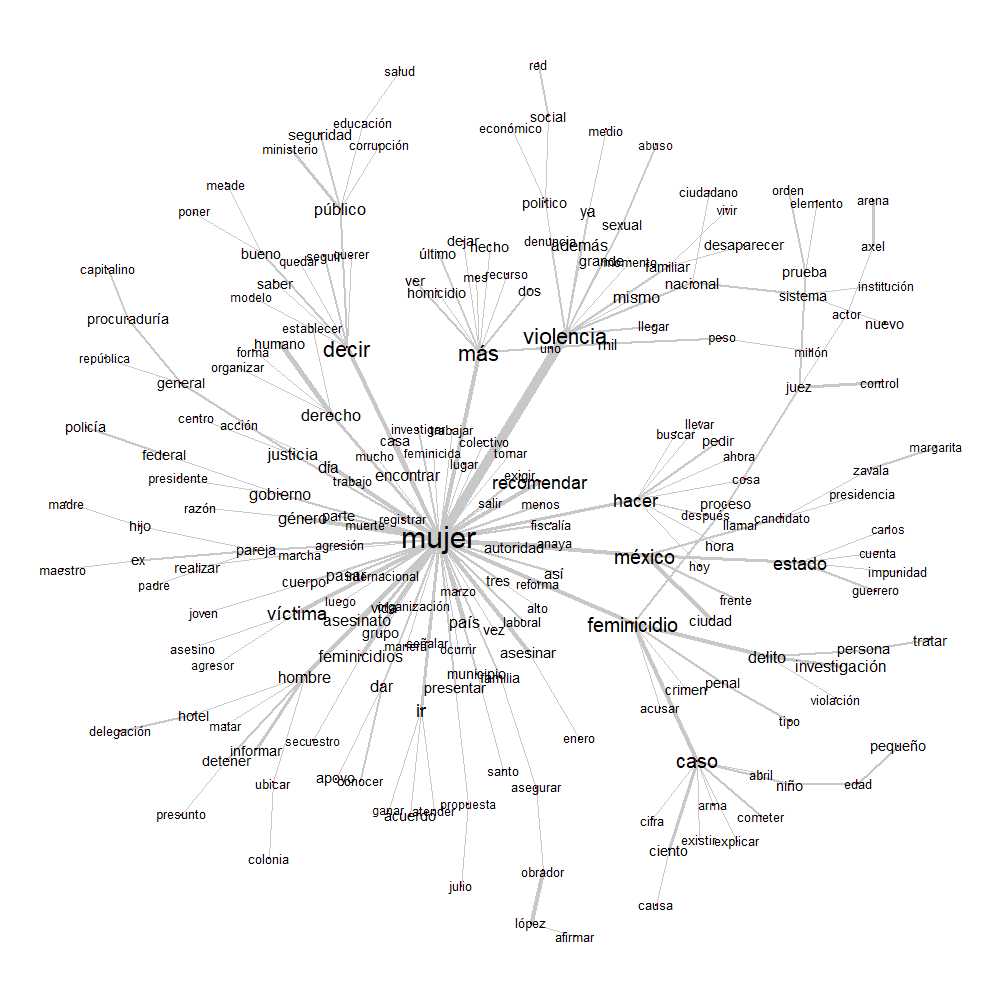

In [40]:
describe_year(
    "mexico",
    2018,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2018,
)

In [41]:
show_chd(
    "mexico",
    2018,
    alceste_run=1,
)

### Clasificación jerárquica descendente

Resultado no encontrado: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2018_corpus_1\corpus_mexico_2018_alceste_1\dendrogramme_1.png


## México 2019



El corpus correspondiente a **Mexico en 2019**
está compuesto por **34 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2019

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2019_corpus_1


### Distribución del tamaño de los segmentos

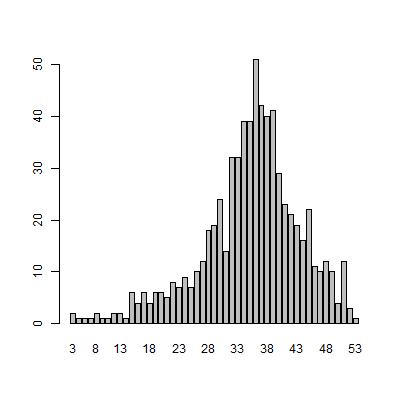

### Distribución de frecuencias léxicas (Zipf)

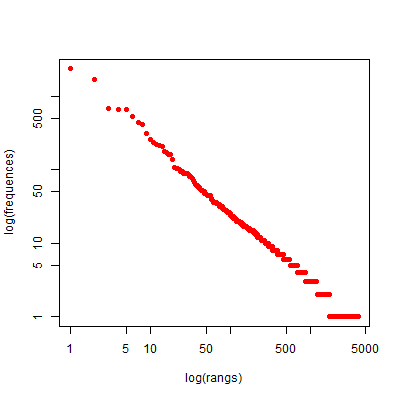

### Nube de palabras

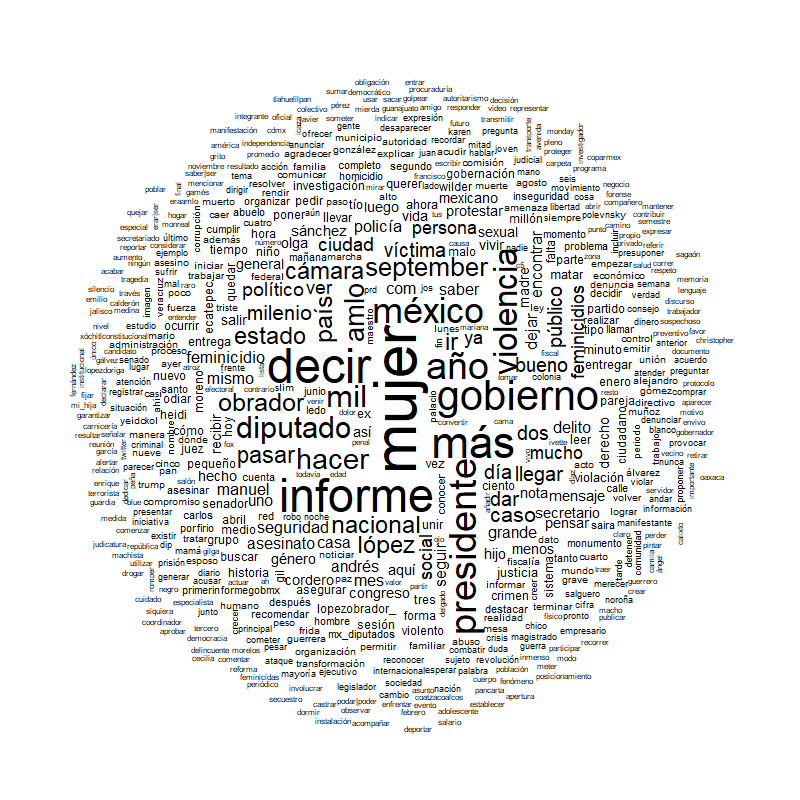

### Análisis de similitud

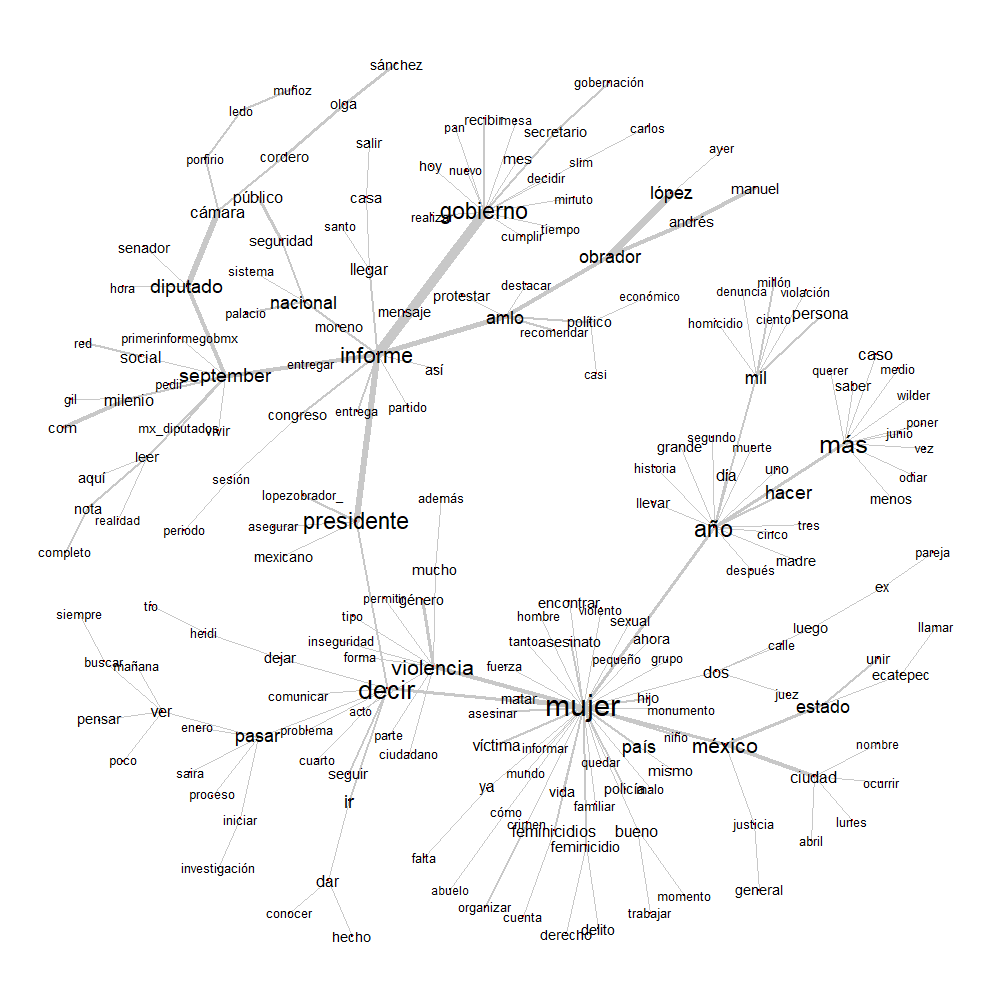

In [42]:
describe_year(
    "mexico",
    2019,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2019,
)

### Clasificación jerárquica descendente

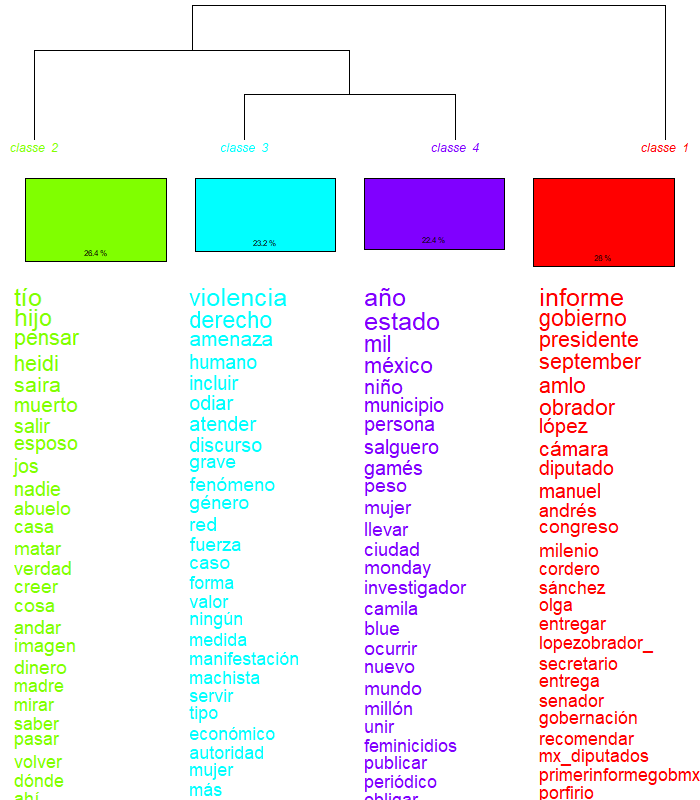

In [43]:
show_chd(
    "mexico",
    2019,
    alceste_run=1,
)

## México 2020



El corpus correspondiente a **Mexico en 2020**
está compuesto por **76 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2020

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2020_corpus_1


### Distribución del tamaño de los segmentos

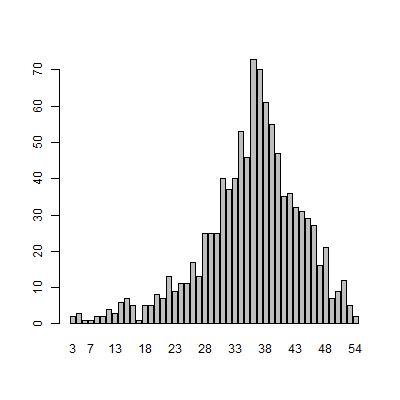

### Distribución de frecuencias léxicas (Zipf)

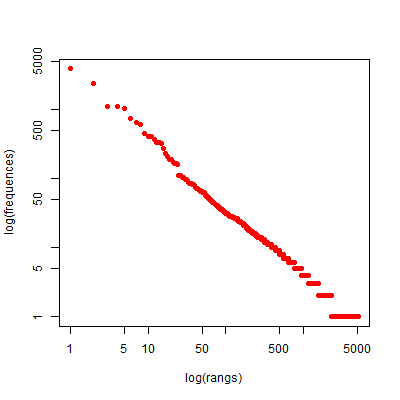

### Nube de palabras

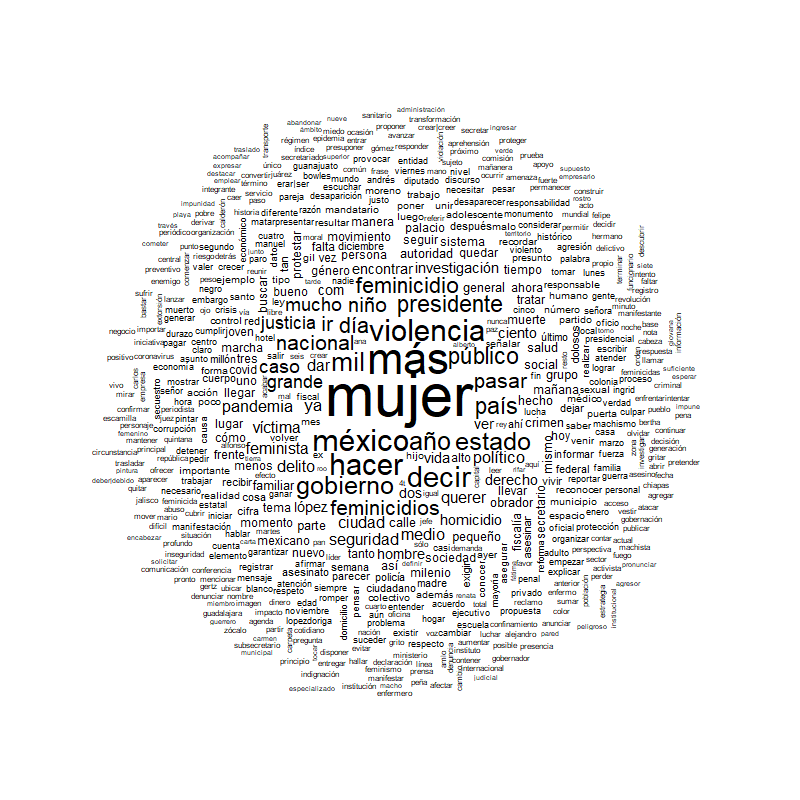

### Análisis de similitud

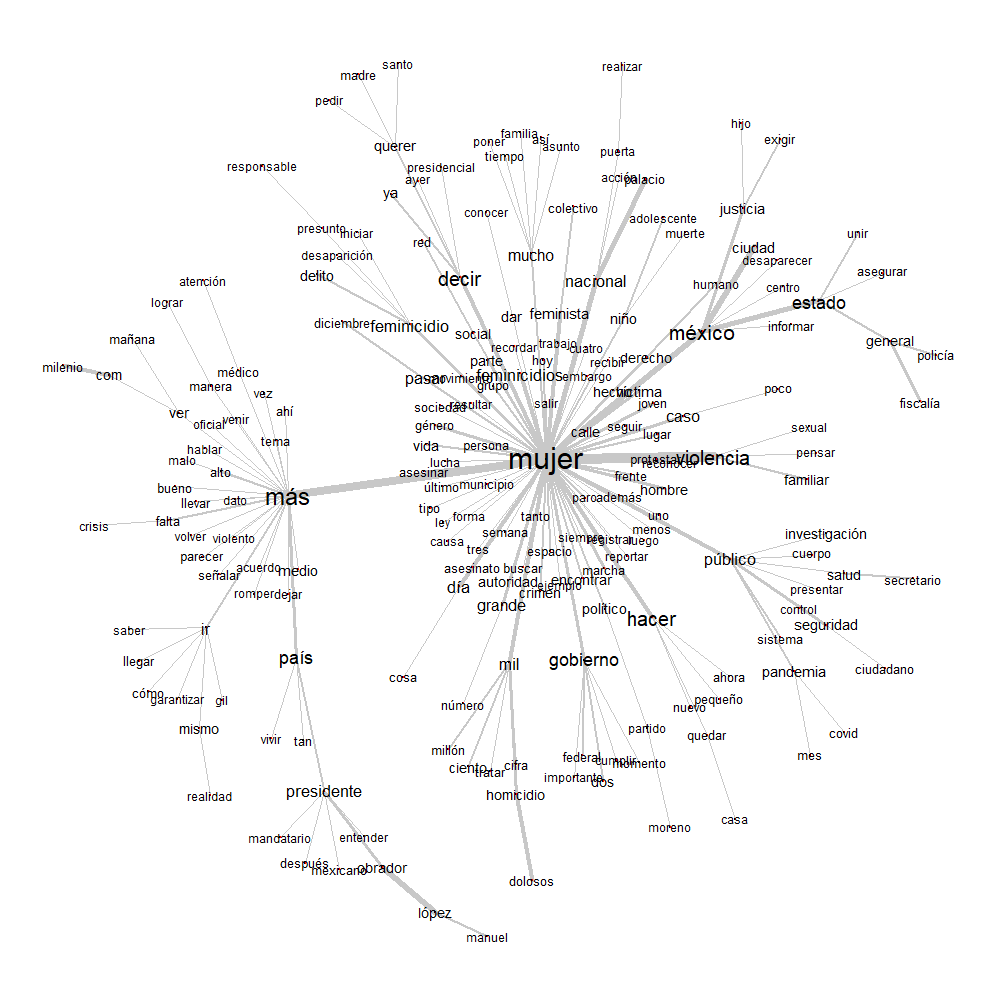

In [44]:
describe_year(
    "mexico",
    2020,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2020,
)

### Clasificación jerárquica descendente

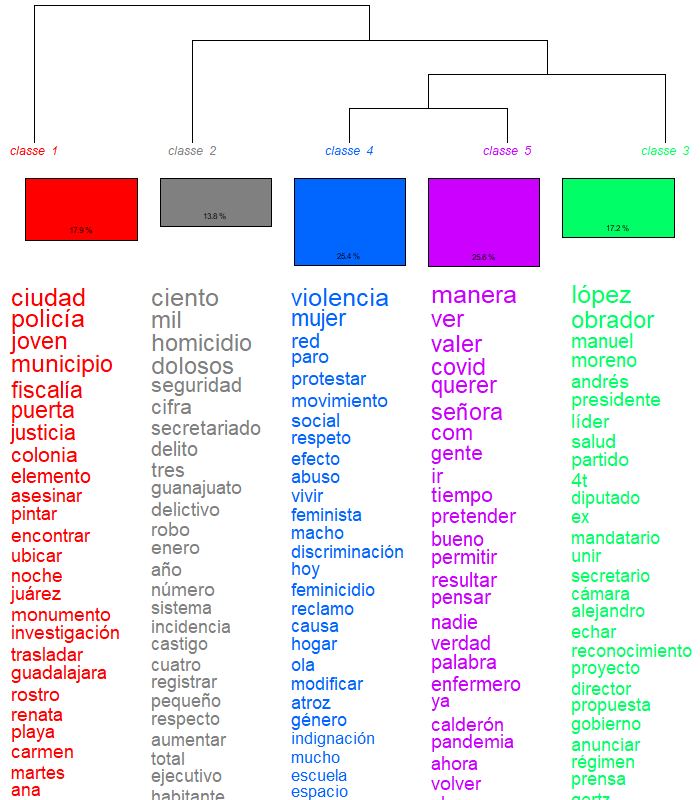

In [45]:
show_chd(
    "mexico",
    2020,
    alceste_run=1,
)

## México 2021



El corpus correspondiente a **Mexico en 2021**
está compuesto por **449 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2021

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2021_corpus_1


### Distribución del tamaño de los segmentos

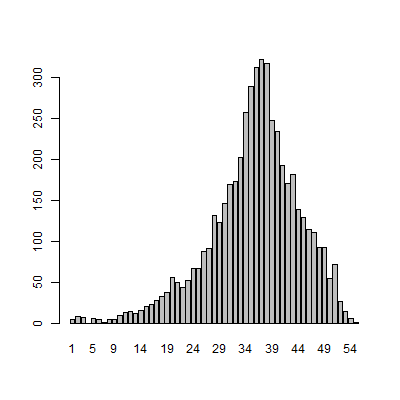

### Distribución de frecuencias léxicas (Zipf)

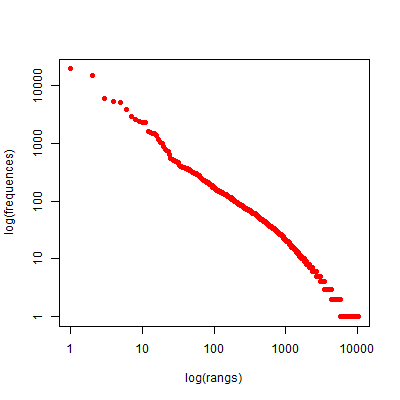

### Nube de palabras

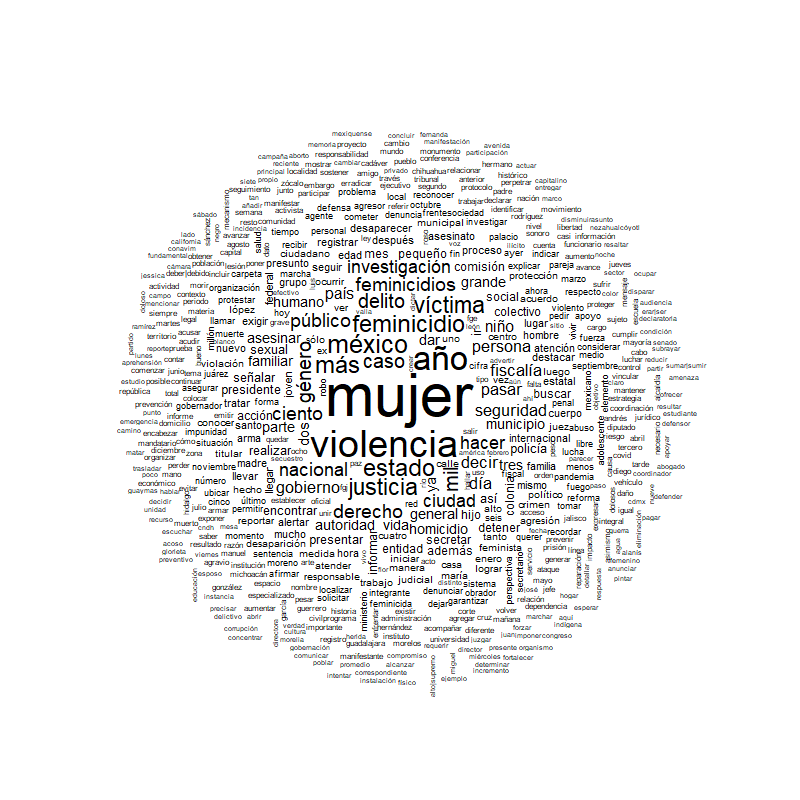

### Análisis de similitud

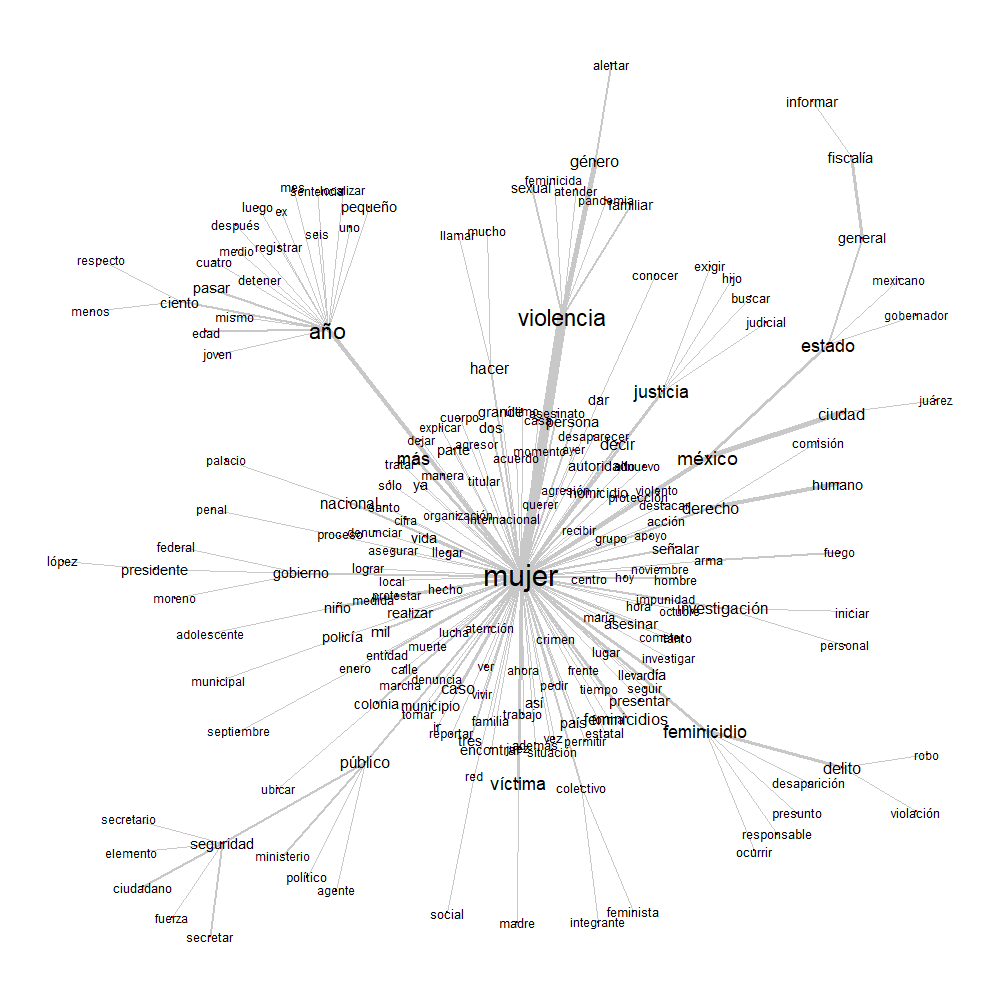

In [46]:
describe_year(
    "mexico",
    2021,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2021,
)

### Clasificación jerárquica descendente

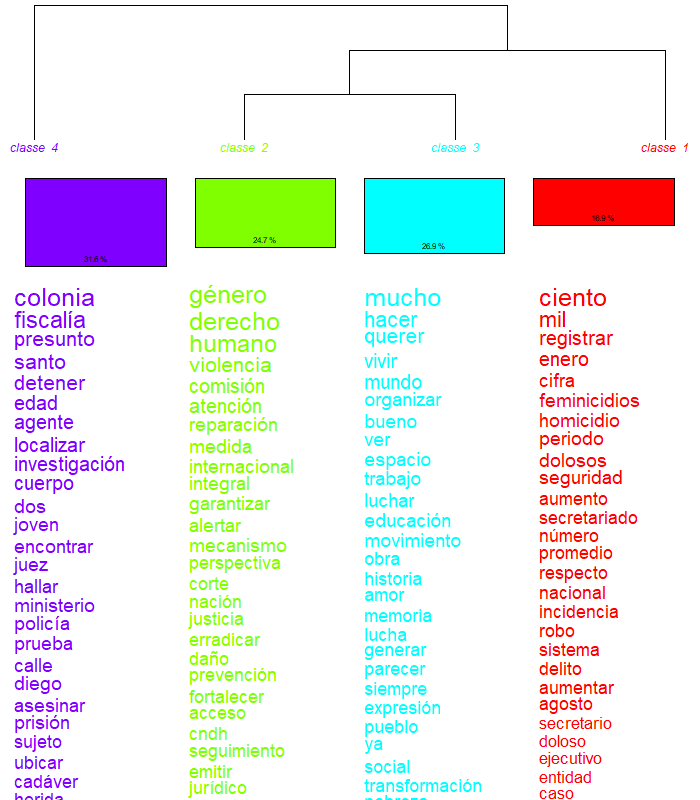

In [47]:
show_chd(
    "mexico",
    2021,
    alceste_run=1,
)

## México 2022



El corpus correspondiente a **Mexico en 2022**
está compuesto por **691 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2022

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2022_corpus_1


### Distribución del tamaño de los segmentos

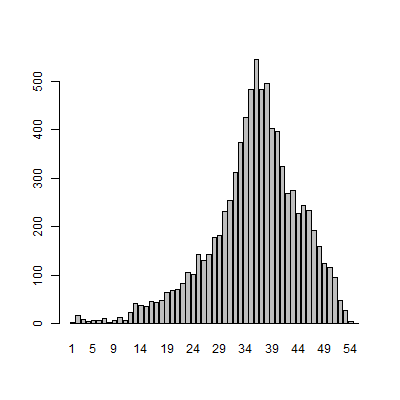

### Distribución de frecuencias léxicas (Zipf)

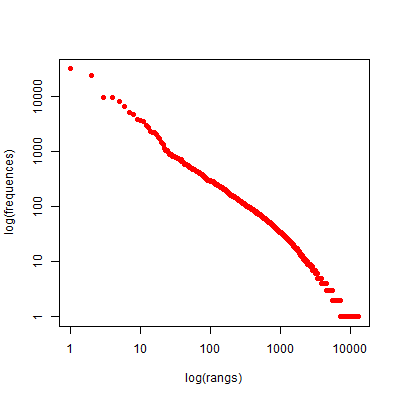

### Nube de palabras

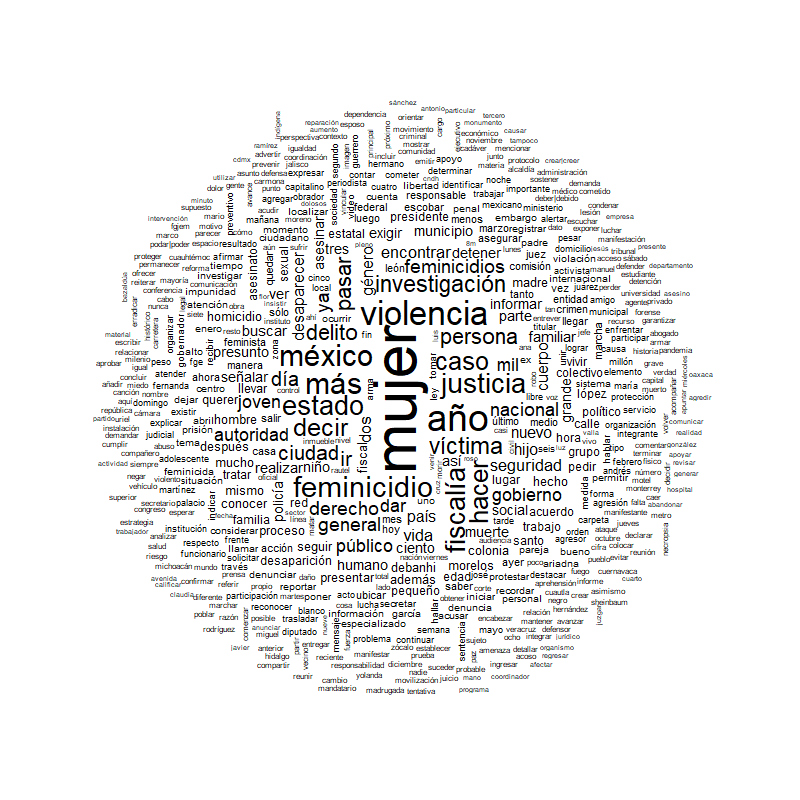

### Análisis de similitud

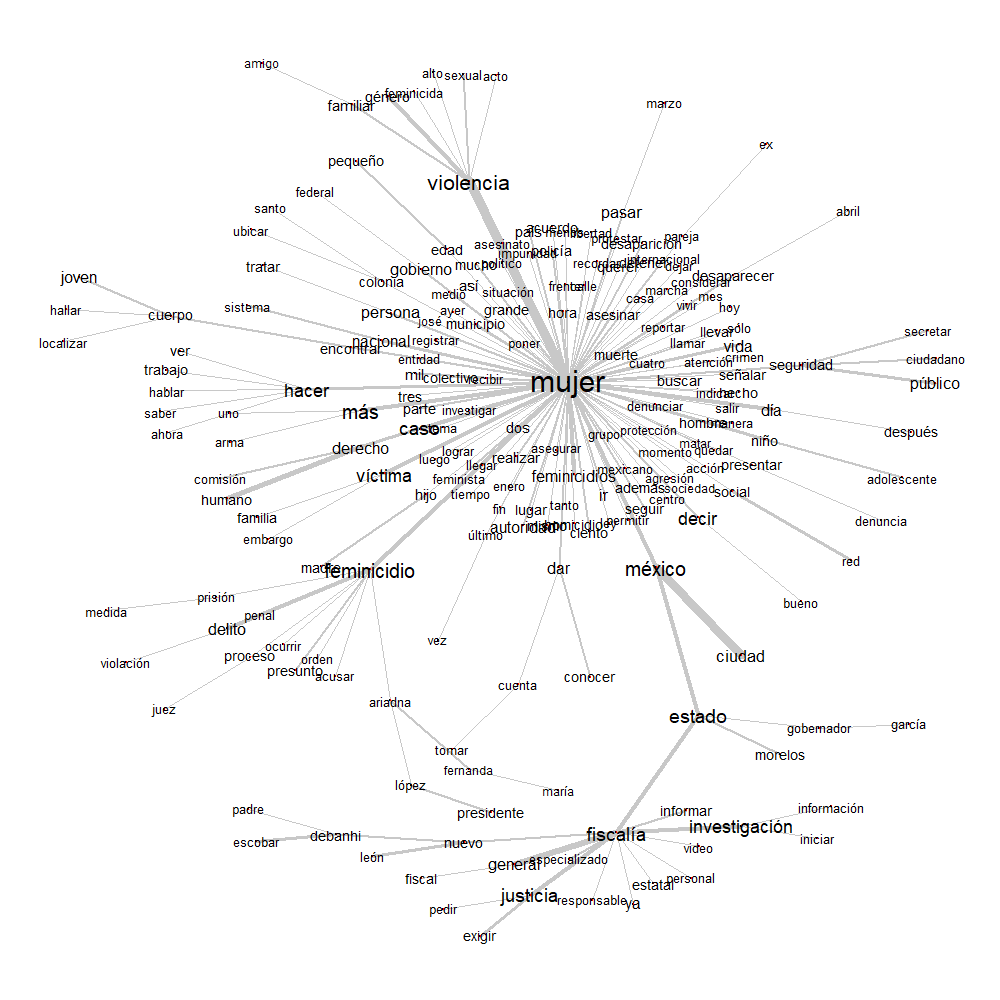

In [48]:
describe_year(
    "mexico",
    2022,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2022,
)

### Clasificación jerárquica descendente

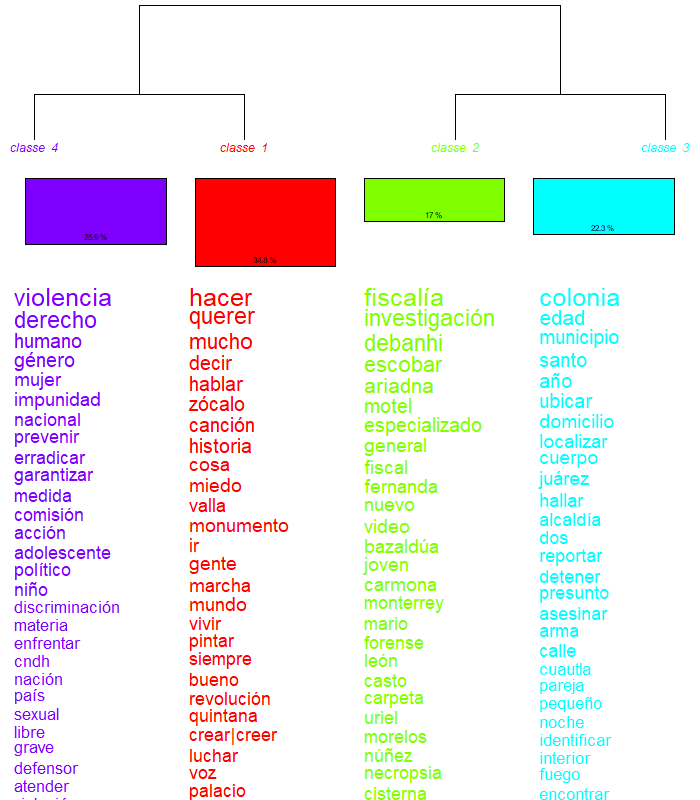

In [49]:
show_chd(
    "mexico",
    2022,
    alceste_run=1,
)

## México 2023



El corpus correspondiente a **Mexico en 2023**
está compuesto por **238 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2023

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2023_corpus_1


### Distribución del tamaño de los segmentos

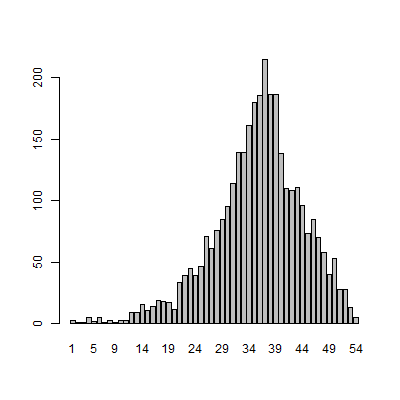

### Distribución de frecuencias léxicas (Zipf)

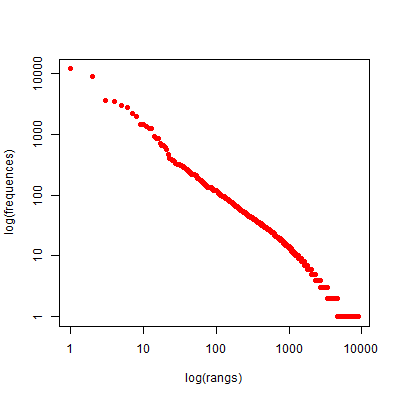

### Nube de palabras

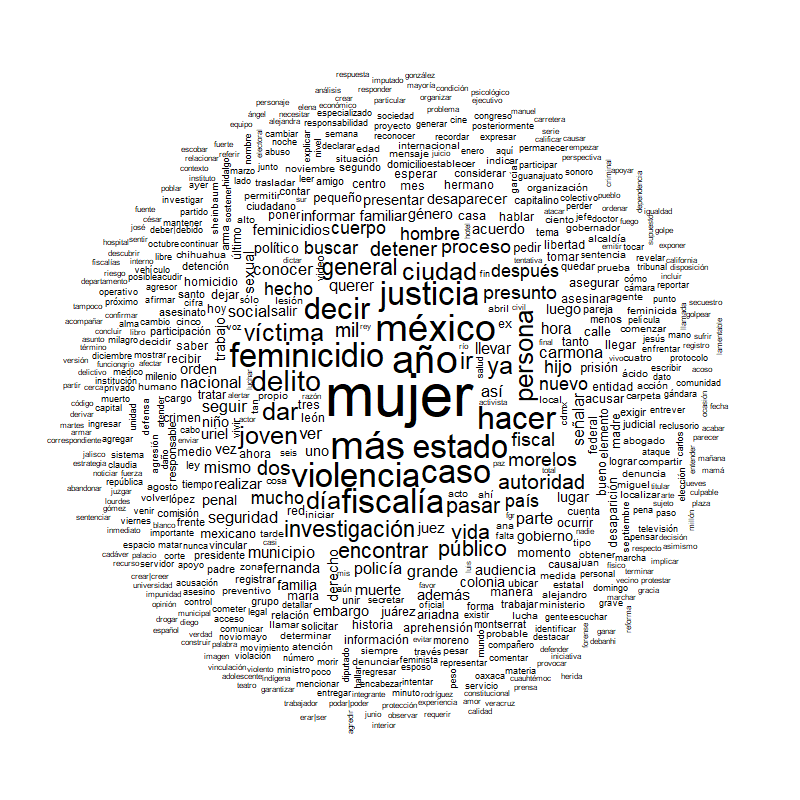

### Análisis de similitud

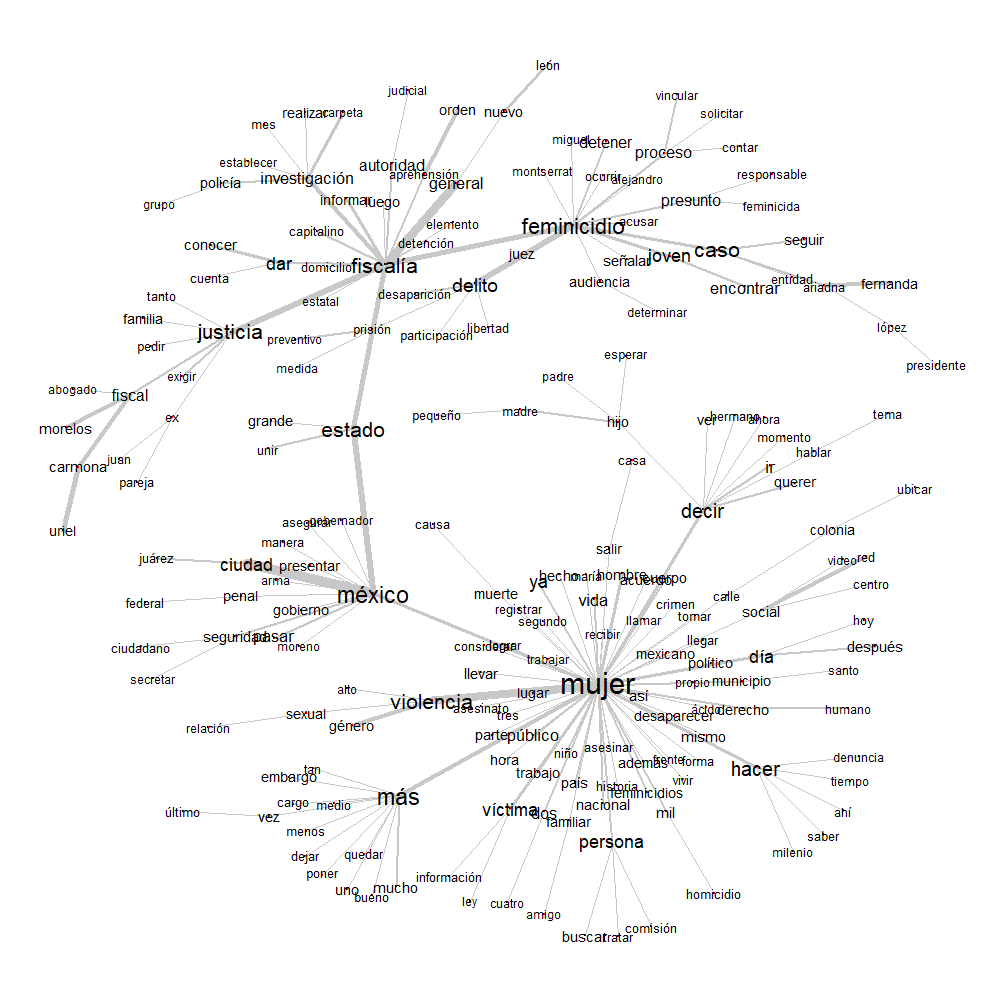

In [50]:
describe_year(
    "mexico",
    2023,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2023,
)

### Clasificación jerárquica descendente

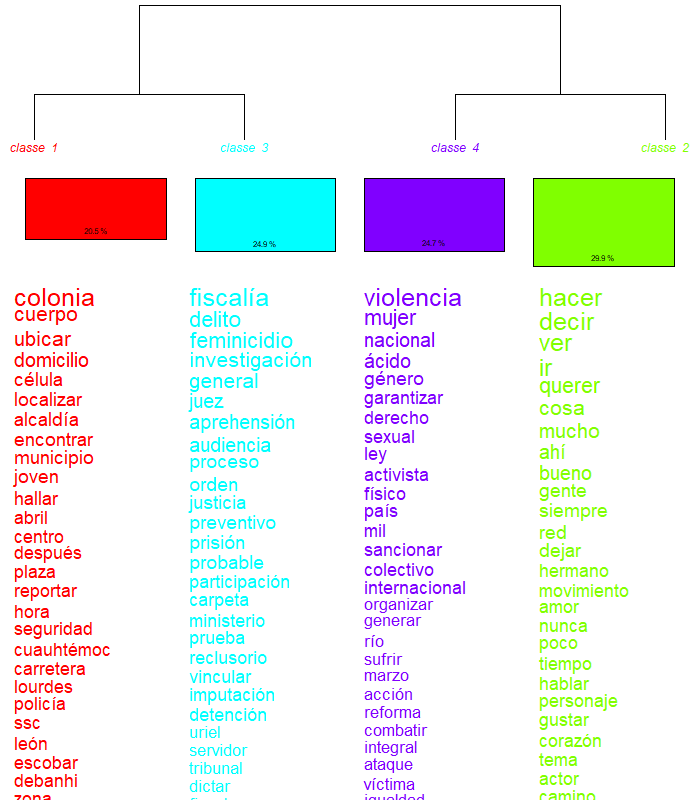

In [51]:
show_chd(
    "mexico",
    2023,
    alceste_run=1,
)

## México 2024



El corpus correspondiente a **Mexico en 2024**
está compuesto por **207 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2024

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2024_corpus_1


### Distribución del tamaño de los segmentos

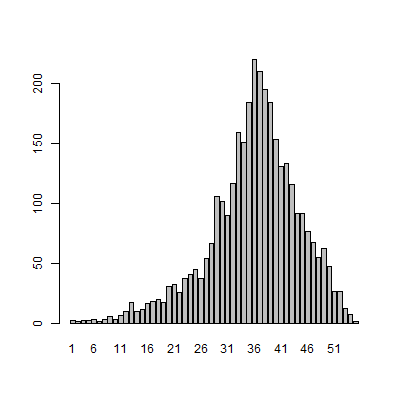

### Distribución de frecuencias léxicas (Zipf)

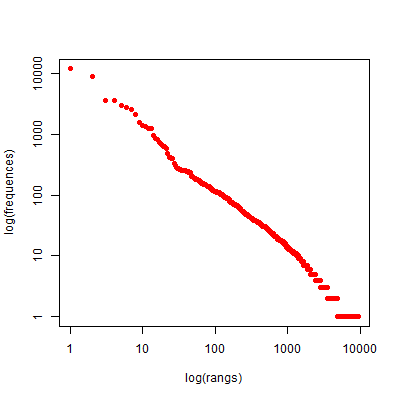

### Nube de palabras

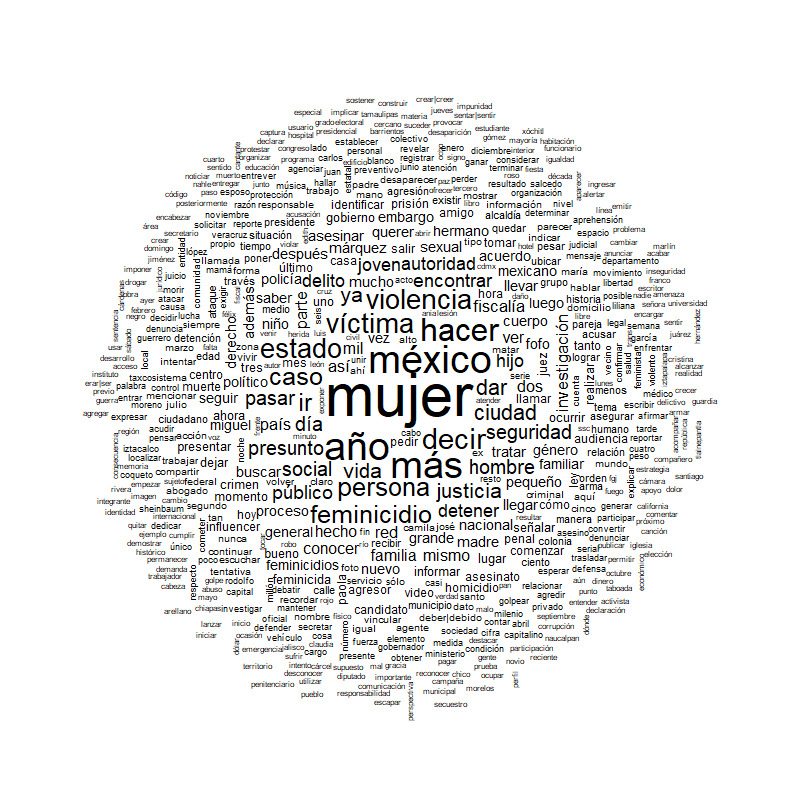

### Análisis de similitud

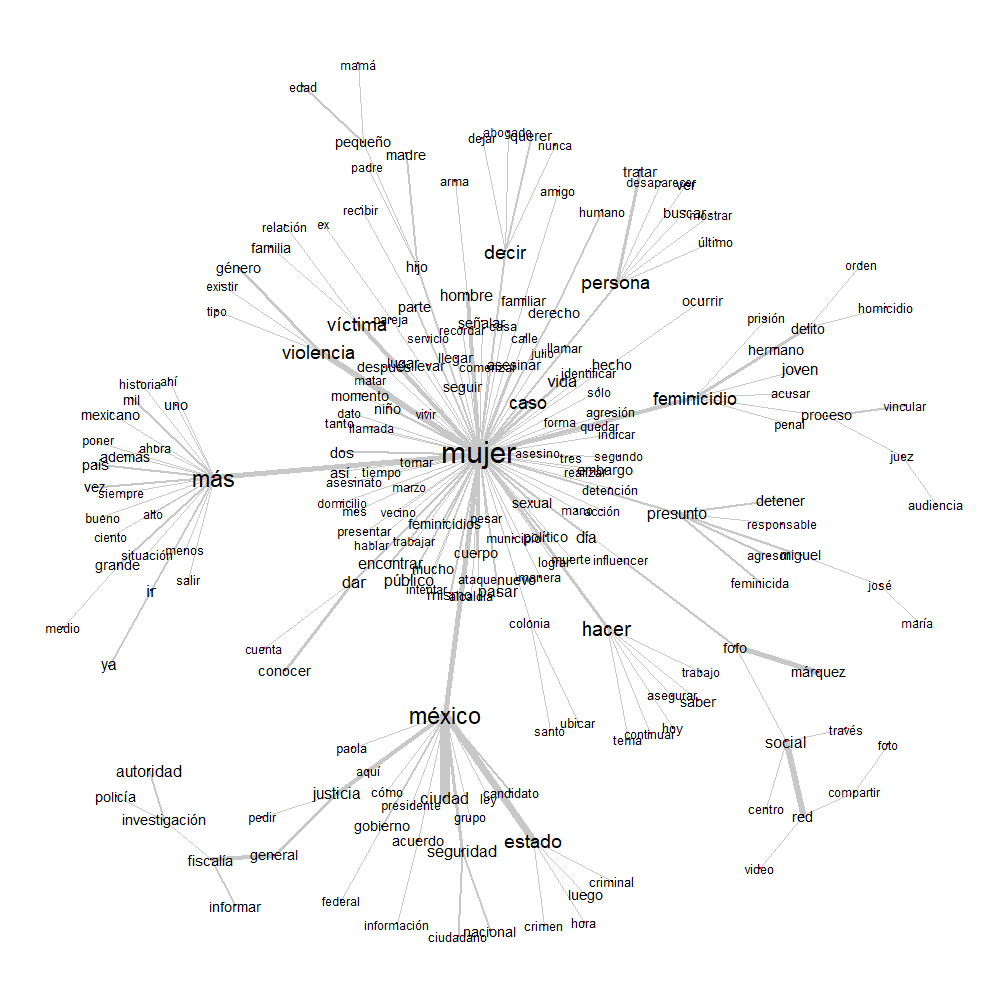

In [52]:
describe_year(
    "mexico",
    2024,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2024,
)

### Clasificación jerárquica descendente

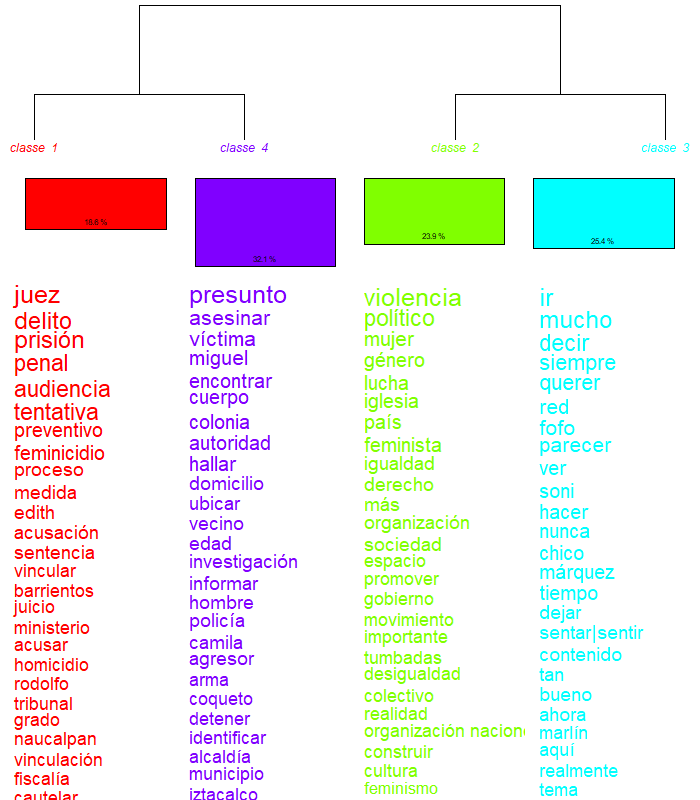

In [53]:
show_chd(
    "mexico",
    2024,
    alceste_run=1,
)

## México 2025



El corpus correspondiente a **Mexico en 2025**
está compuesto por **237 noticias**.

Se realizó una exploración textual mediante IRaMuTeQ que incluyó
estadísticas léxicas, distribución de frecuencias, nube de palabras
y análisis de similitud. El objetivo es caracterizar la estructura
léxica del periodo y detectar posibles diferencias con los años
anteriores y posteriores.


## Mexico — 2025

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\by_year\corpus_mexico_2025_corpus_1


### Distribución del tamaño de los segmentos

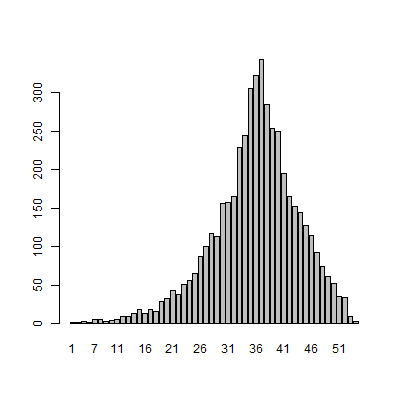

### Distribución de frecuencias léxicas (Zipf)

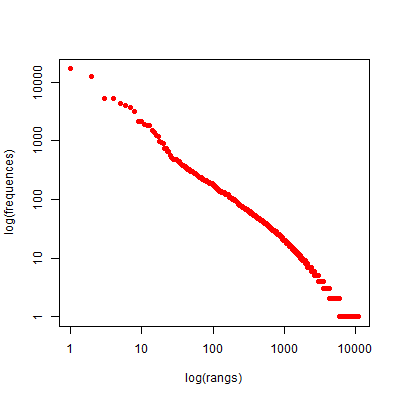

### Nube de palabras

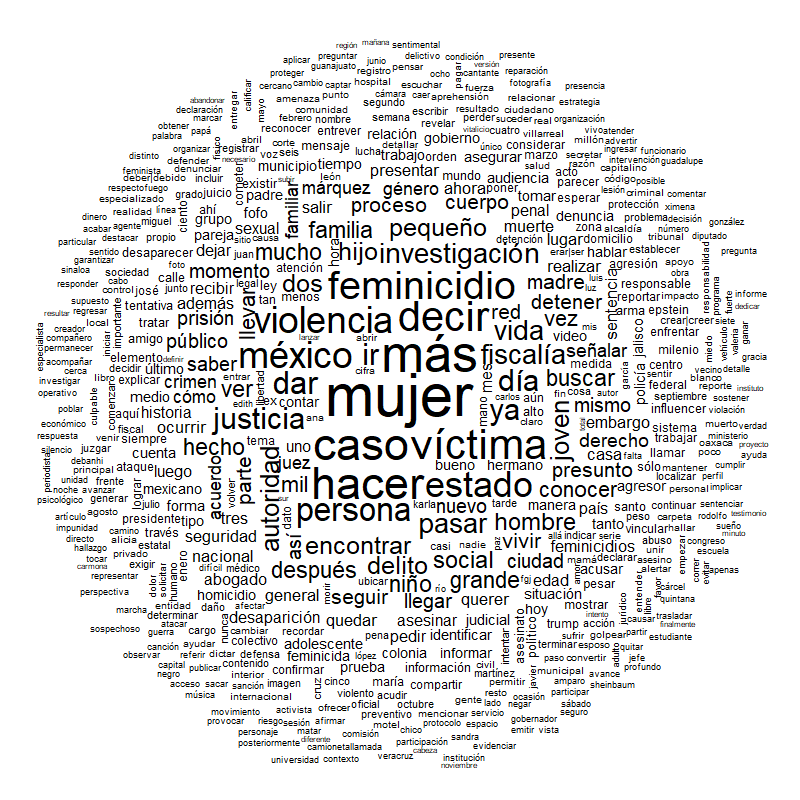

### Análisis de similitud

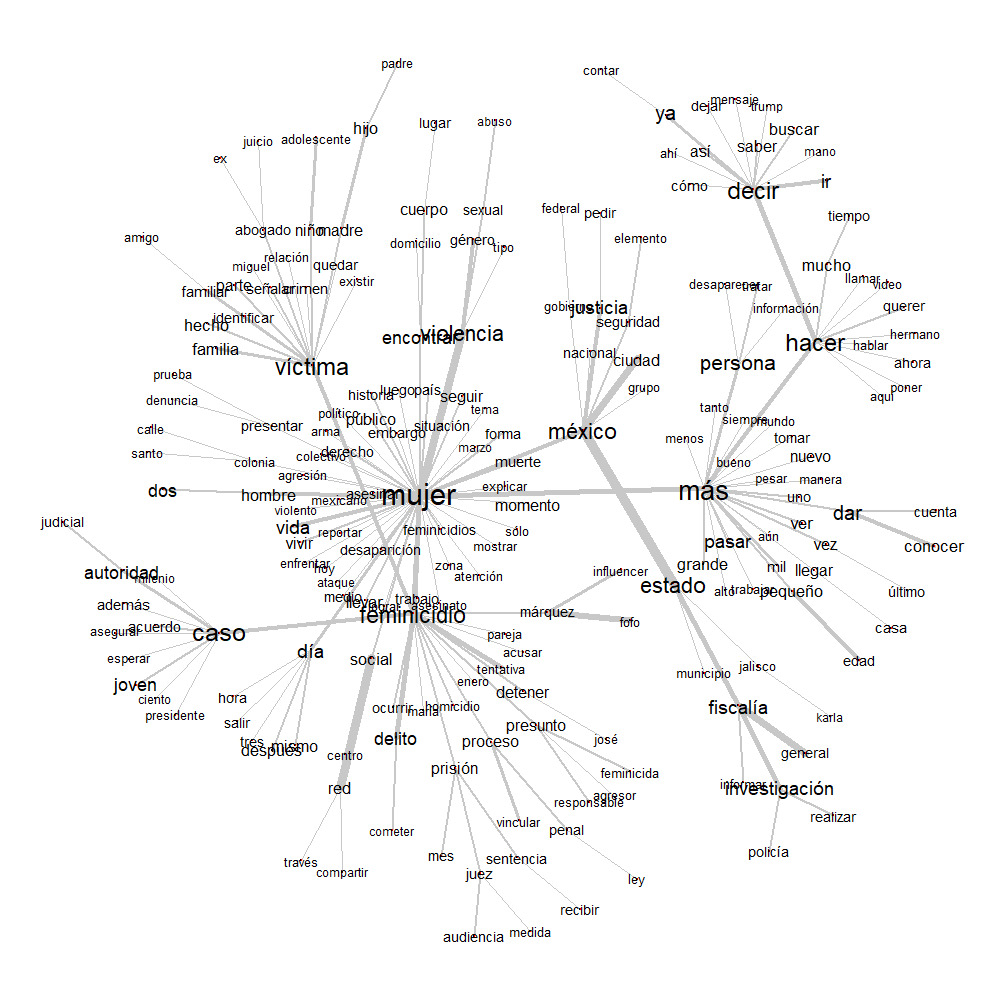

In [54]:
describe_year(
    "mexico",
    2025,
    mexico_manifest,
)

show_results(
    "mexico",
    year=2025,
)

### Clasificación jerárquica descendente

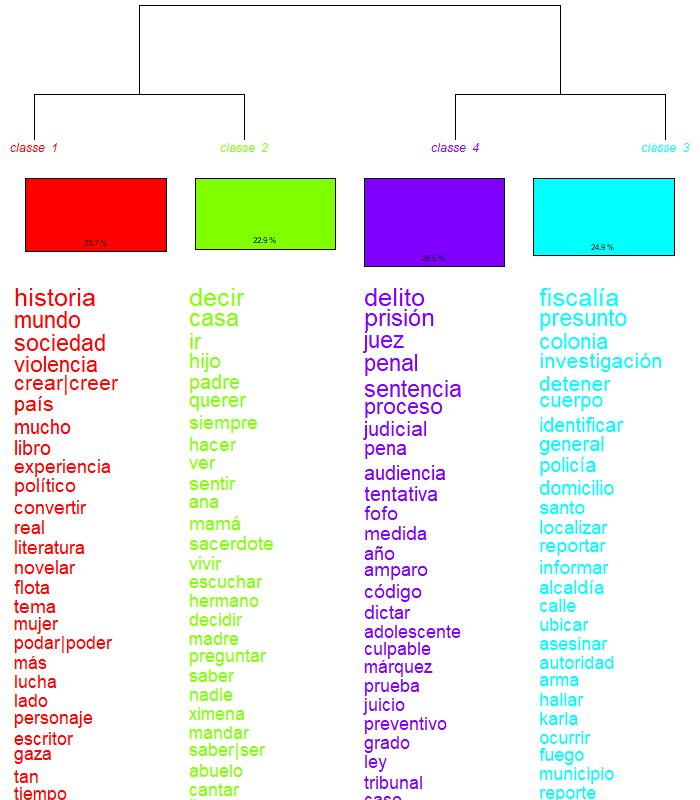

In [55]:
show_chd(
    "mexico",
    2025,
    alceste_run=1,
)

# 3. Análisis global por país

Tras la exploración anual, se analizaron de forma independiente los
corpus completos de Argentina y México para el periodo 2015–2025.

El corpus argentino contiene 1196 noticias y el mexicano 2204.

Para cada país se realizaron análisis estadísticos y léxicos, análisis
de similitud, clasificación jerárquica descendente y análisis de
especificidades y correspondencias.

## Argentina

In [64]:
argentina_global = (
    IRAMUTEQ_DIR
    / "argentina"
    / "corpus_argentina_2015_2025_corpus_1"
)

## Argentina — 2015–2025

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\argentina\corpus_argentina_2015_2025_corpus_1


### Distribución del tamaño de los segmentos

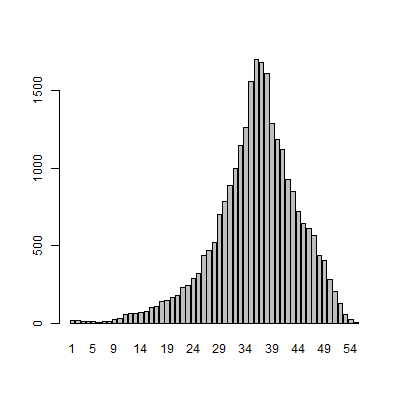

### Distribución de frecuencias léxicas (Zipf)

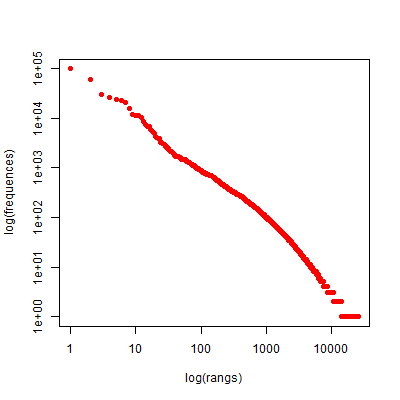

### Nube de palabras

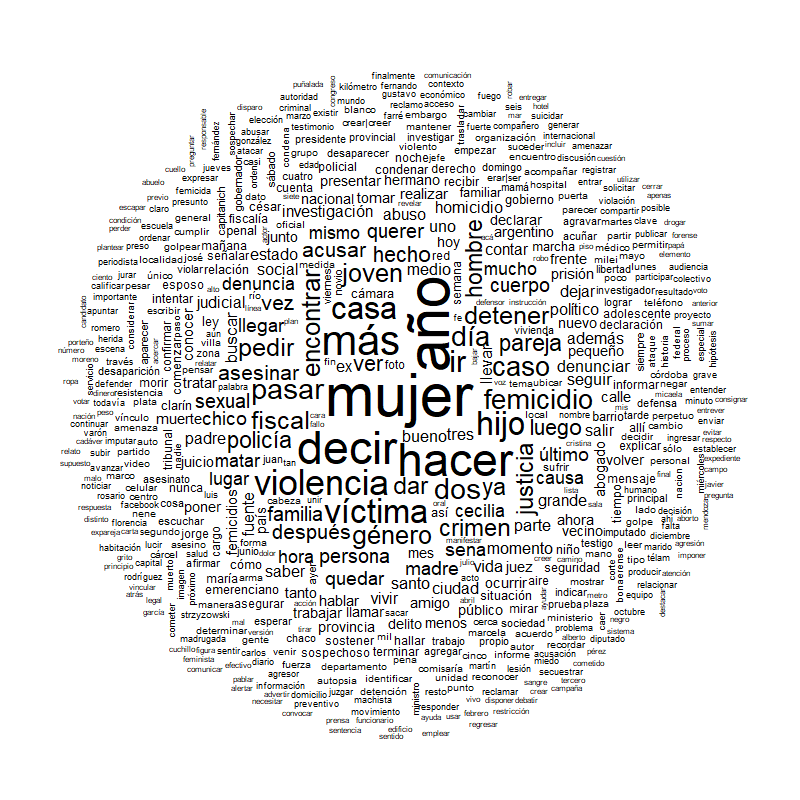

### Análisis de similitud

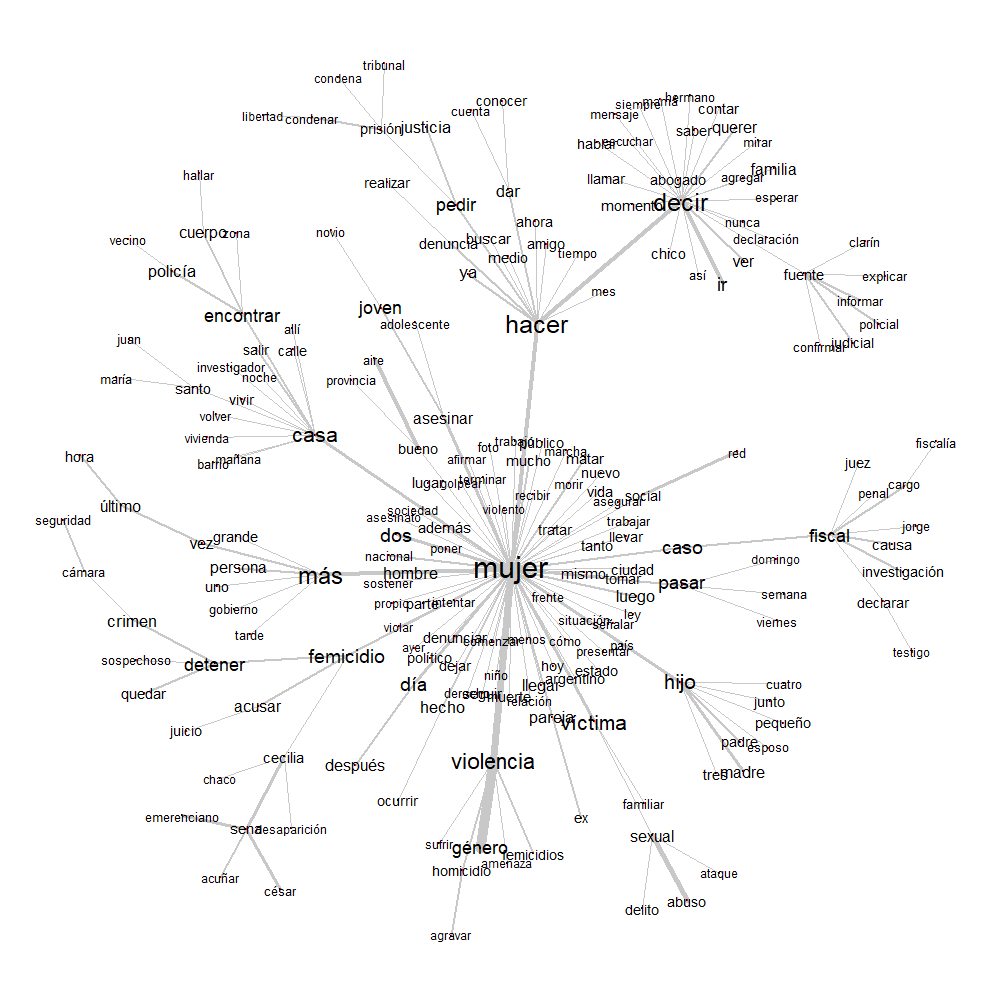

In [56]:
show_results(
    "argentina",
)

### Clasificación jerárquica descendente

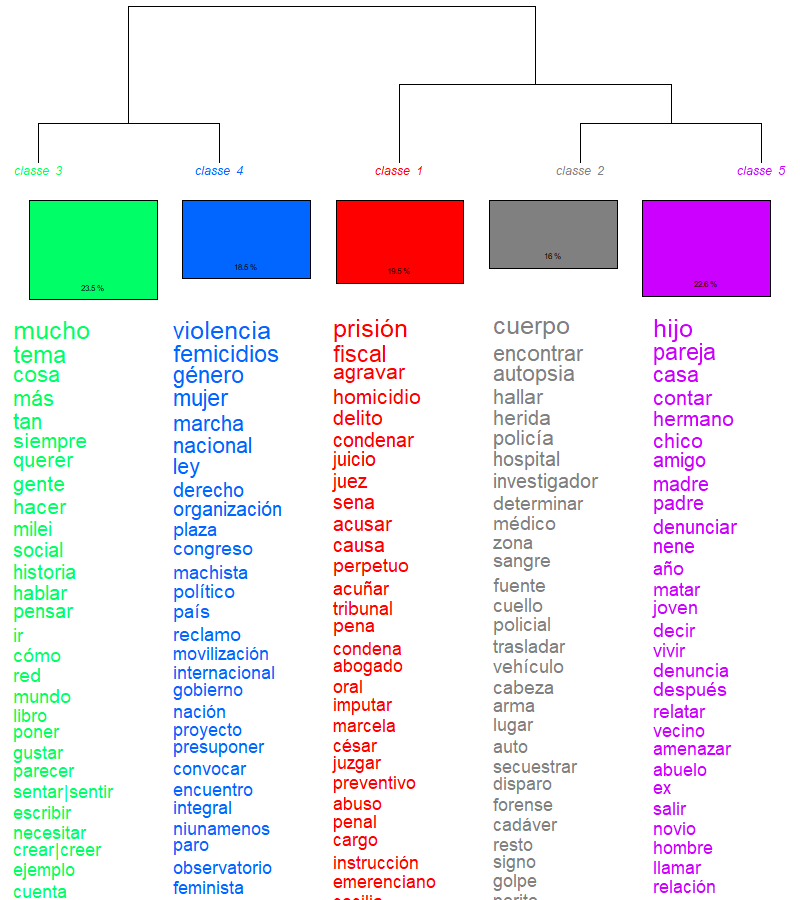

In [57]:
show_global_chd(
    "argentina",
    alceste_run=1,
)

### Argentina — AFC global por año

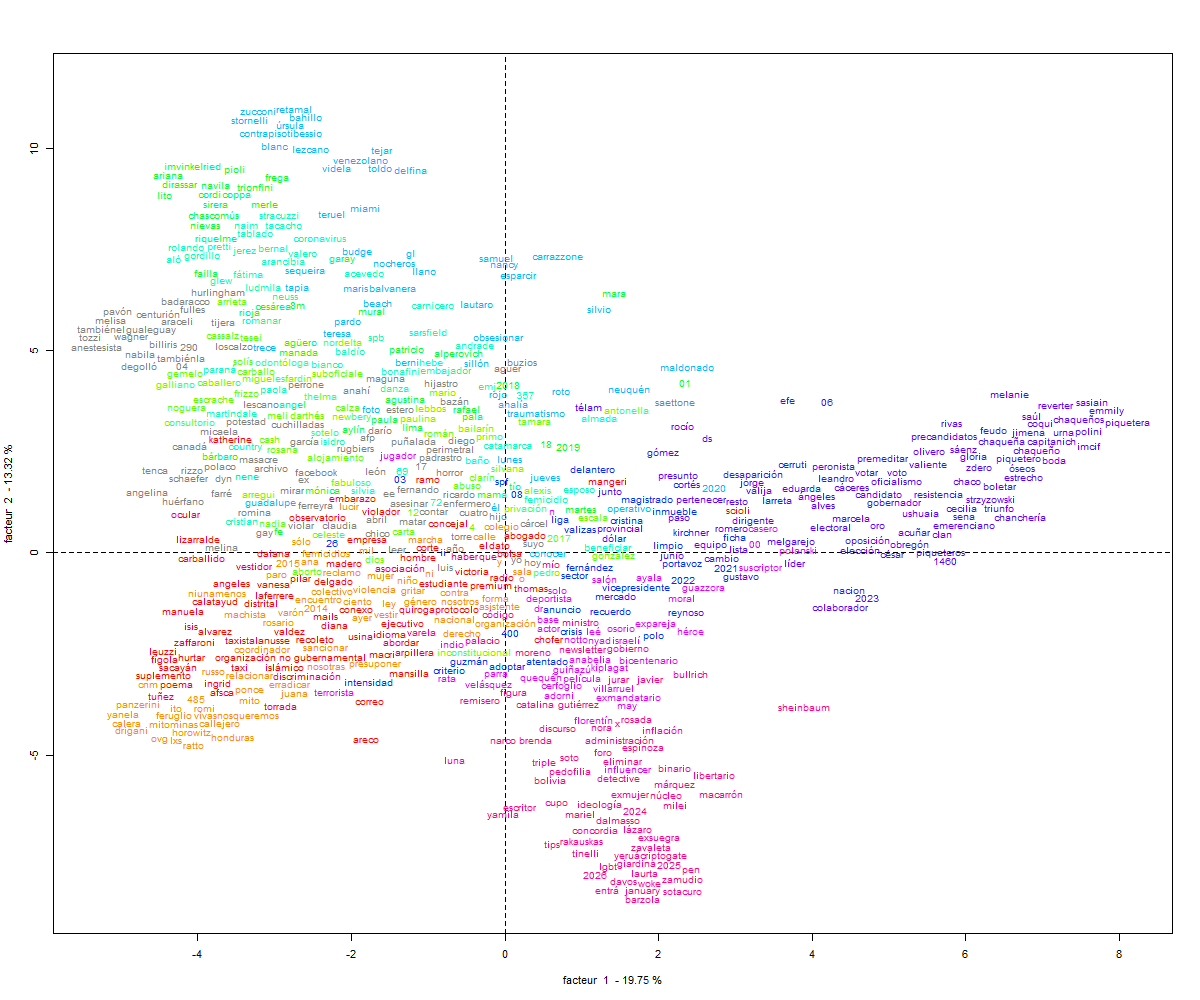

### Argentina — AFC global por medio

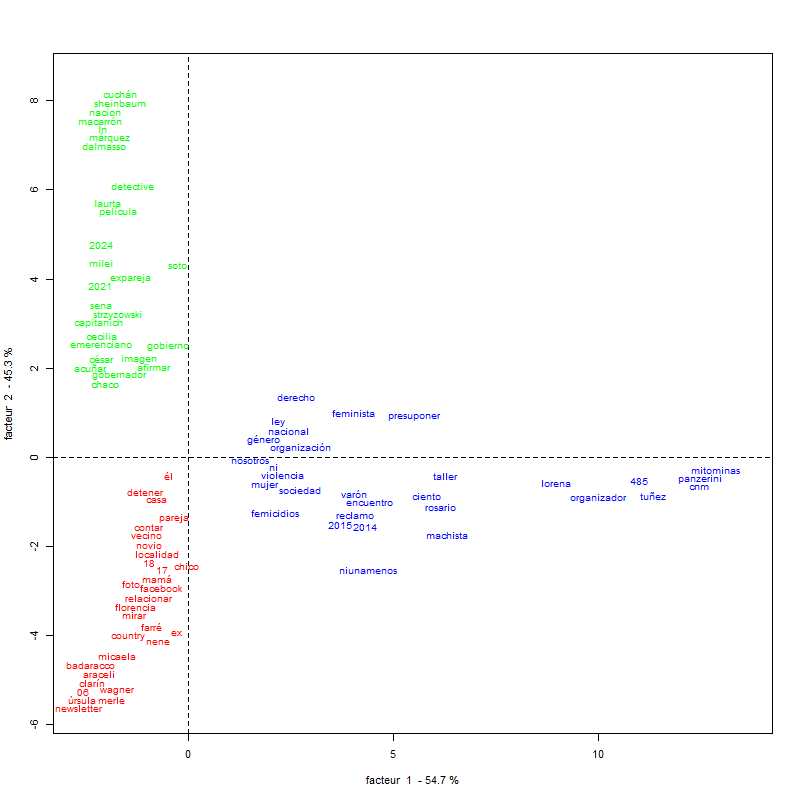

In [66]:
# ----------------------------------------------------------
# ARGENTINA
# ----------------------------------------------------------

show_selected_image(
    argentina_global
    / "corpus_argentina_2015_2025_spec_1"
    / "graph_afc_3.png",
    "Argentina — AFC global por año",
)

show_selected_image(
    argentina_global
    / "corpus_argentina_2015_2025_spec_2"
    / "graph_afc_1.png",
    "Argentina — AFC global por medio",
)

## México

In [67]:
mexico_global = (
    IRAMUTEQ_DIR
    / "mexico"
    / "corpus_mexico_2015_2025_corpus_1"
)

## Mexico — 2015–2025

Directorio IRaMuTeQ: ..\outputs\analysis\2015_2025\iramuteq\mexico\corpus_mexico_2015_2025_corpus_1


### Distribución del tamaño de los segmentos

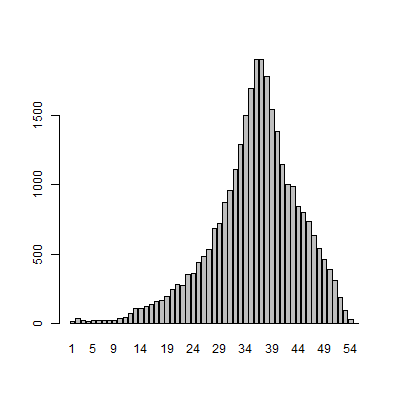

### Distribución de frecuencias léxicas (Zipf)

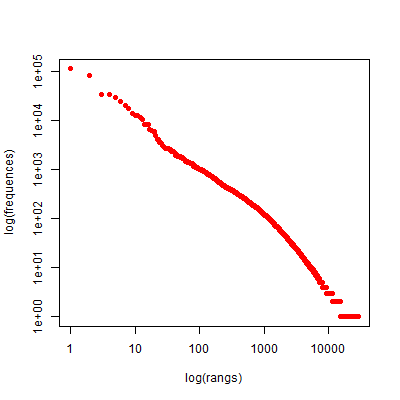

### Nube de palabras

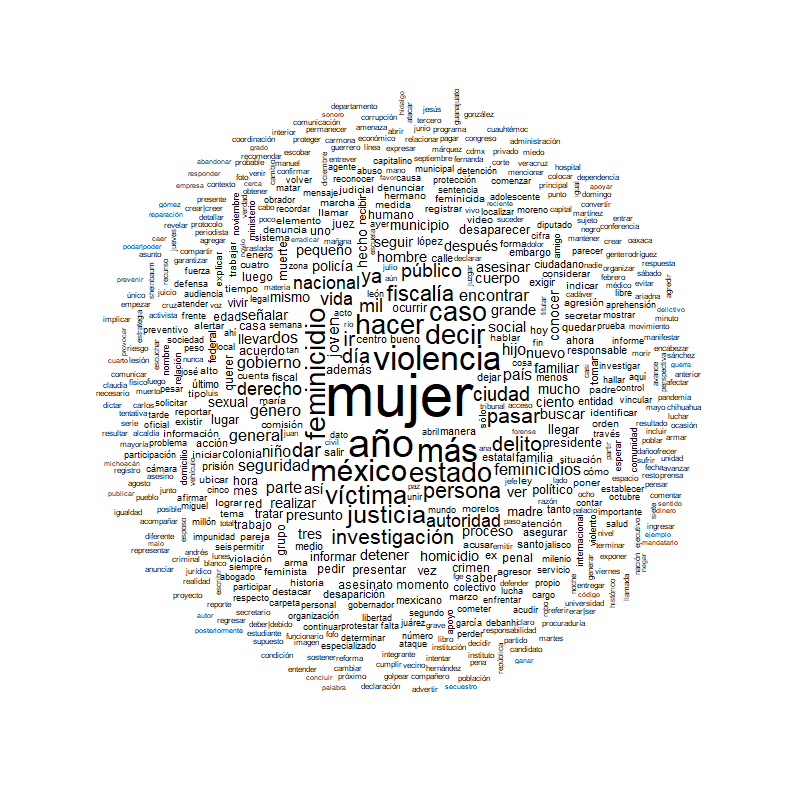

### Análisis de similitud

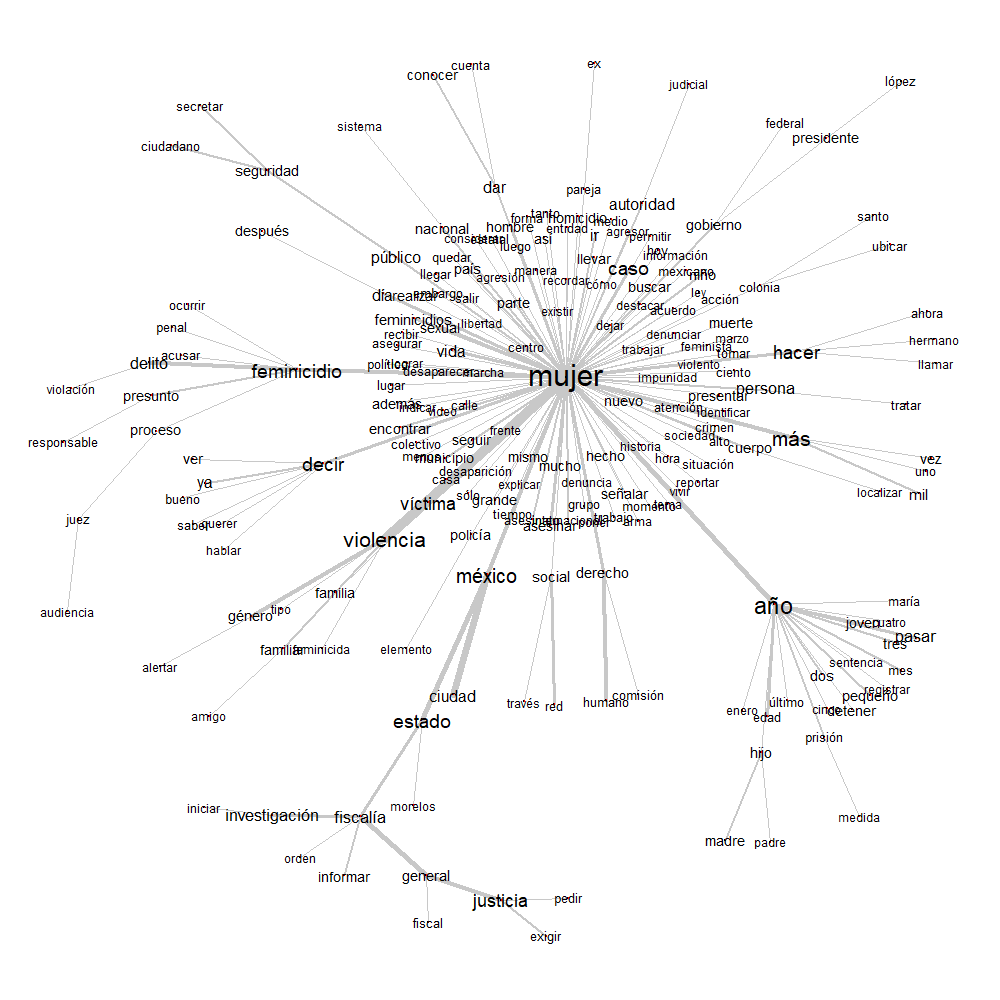

In [58]:
show_results(
    "mexico"
)

### Clasificación jerárquica descendente

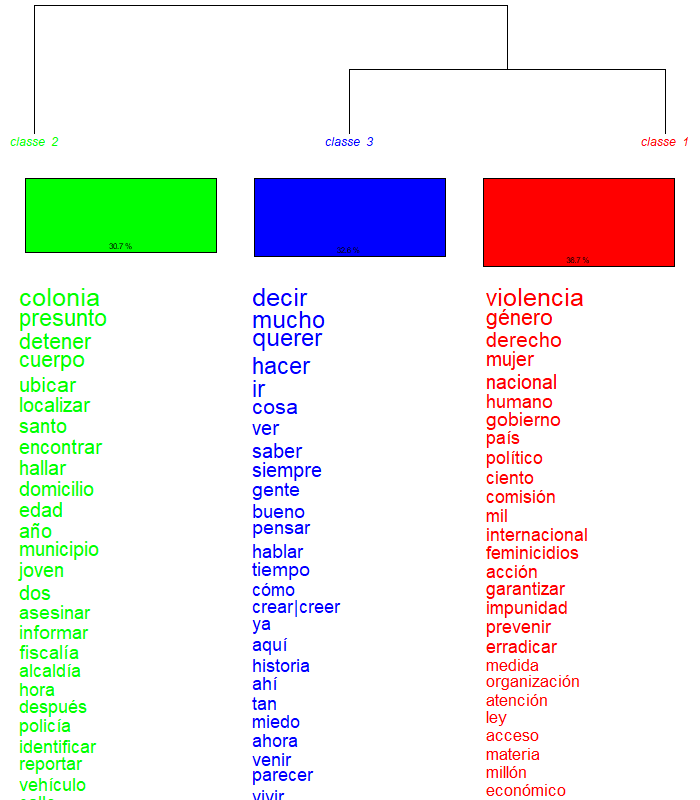

In [59]:
show_global_chd(
    "mexico",
    alceste_run=1,
)

### México — AFC global por año

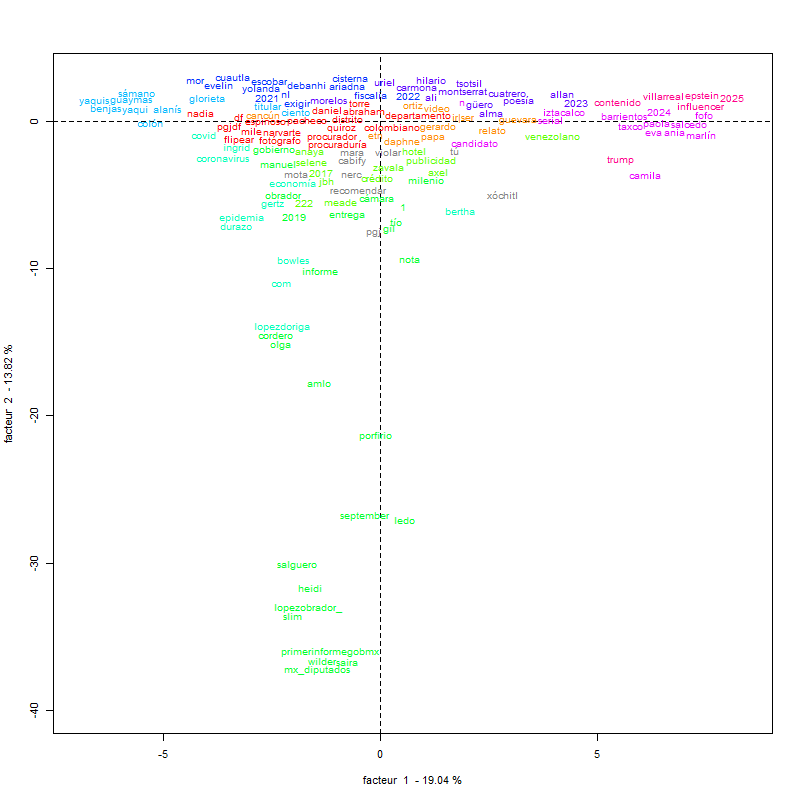

### México — AFC global por medio

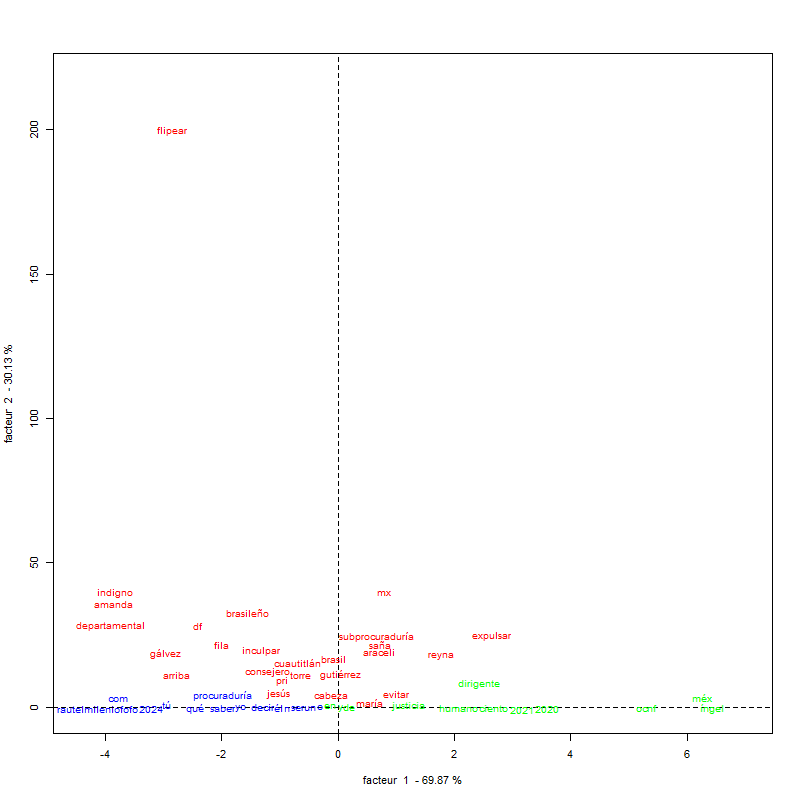

In [68]:
show_selected_image(
    mexico_global
    / "corpus_mexico_2015_2025_spec_2"
    / "graph_afc_1.png",
    "México — AFC global por año",
)

show_selected_image(
    mexico_global
    / "corpus_mexico_2015_2025_spec_3"
    / "graph_afc_1.png",
    "México — AFC global por medio",
)